# DTU Data Exploration and Analysis

In [118]:
from pathlib import Path
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import numpy as np
import statsmodels.api as sm

In [119]:
FEEDBACK_PATH = "data/raw/dtu/feedback"
SERIES_PATH = "data/raw/dtu/timeseries"


## Loading timeseries and feedback files

In [120]:
files = [p.name for p in Path(FEEDBACK_PATH).iterdir() if p.is_file()]
files = [filename for filename in files if filename.endswith(".csv") and "Room" in filename]

df_dict = {} 

for filename in files:
    room_name = filename.split(".")[0]
    feedback_path = Path(FEEDBACK_PATH) / filename
    series_path = Path(SERIES_PATH) / filename

    feedback_df = pd.read_csv(feedback_path)
    series_df = pd.read_csv(series_path)

    df_dict[room_name] = {
        "feedback": feedback_df,
        "series": series_df
    }

print(f"Loaded data for {len(df_dict)} rooms.")
for room_name, data in df_dict.items():
    print(f"Room: {room_name}")
    print(f"Feedback shape: {data['feedback'].shape}")
    print(f"Series shape: {data['series'].shape}")
    print(f"CO2 Nan values of Timeseries: {data['series']['co2'].isna().sum()}") 
    print()

Loaded data for 11 rooms.
Room: Room 009
Feedback shape: (29, 3)
Series shape: (41424, 9)
CO2 Nan values of Timeseries: 27076

Room: Room 019
Feedback shape: (44, 3)
Series shape: (43069, 12)
CO2 Nan values of Timeseries: 28729

Room: Room 054
Feedback shape: (12, 3)
Series shape: (71449, 9)
CO2 Nan values of Timeseries: 43450

Room: Room 001
Feedback shape: (1, 3)
Series shape: (23875, 5)
CO2 Nan values of Timeseries: 9583

Room: Room 015
Feedback shape: (52, 3)
Series shape: (24115, 5)
CO2 Nan values of Timeseries: 9774

Room: Room 016
Feedback shape: (14, 3)
Series shape: (28746, 9)
CO2 Nan values of Timeseries: 14411

Room: Room 007
Feedback shape: (17, 3)
Series shape: (41717, 9)
CO2 Nan values of Timeseries: 27379

Room: Room 012
Feedback shape: (16, 3)
Series shape: (41760, 9)
CO2 Nan values of Timeseries: 27413

Room: Room 004
Feedback shape: (4, 3)
Series shape: (37658, 9)
CO2 Nan values of Timeseries: 23387

Room: Room 010
Feedback shape: (12, 3)
Series shape: (30721, 8)
CO2 

| Room | Feedback shape | Series shape | CO2 NaN values |
|------|----------------|--------------|-----------------|
| Room 009 | (29, 3) | (41424, 9) | 27076 |
| Room 019 | (44, 3) | (43069, 12) | 28729 |
| Room 054 | (12, 3) | (71449, 9) | 43450 |
| Room 001 | (1, 3) | (23875, 5) | 9583 |
| Room 015 | (52, 3) | (24115, 5) | 9774 |
| Room 016 | (14, 3) | (28746, 9) | 14411 |
| Room 007 | (17, 3) | (41717, 9) | 27379 |
| Room 012 | (16, 3) | (41760, 9) | 27413 |
| Room 004 | (4, 3) | (37658, 9) | 23387 |
| Room 010 | (12, 3) | (30721, 8) | 16418 |
| Room 039 | (3, 3) | (13797, 4) | 0 |

In [121]:
from collections import Counter

series_col_counts = Counter()
feedback_col_counts = Counter()
n_dfs = len(df_dict)

for room_name, data in df_dict.items():
    series_cols = data["series"].columns
    feedback_cols = data["feedback"].columns

    series_col_counts.update(set(series_cols))
    feedback_col_counts.update(set(feedback_cols))

for col, count in series_col_counts.items():
    print(f"Series column: {col} appears in {count} dataframes")

for col, count in feedback_col_counts.items():
    print(f"Feedback column: {col} appears in {count} dataframes")


Series column: humidity appears in 11 dataframes
Series column: motor_range appears in 7 dataframes
Series column: target_temperature appears in 7 dataframes
Series column: closed appears in 8 dataframes
Series column: trv_temperature appears in 7 dataframes
Series column: motor_position appears in 7 dataframes
Series column: datetime appears in 11 dataframes
Series column: temperature appears in 11 dataframes
Series column: co2 appears in 11 dataframes
Series column: motor_range_x appears in 1 dataframes
Series column: target_temperature_y appears in 1 dataframes
Series column: trv_temperature_y appears in 1 dataframes
Series column: trv_temperature_x appears in 1 dataframes
Series column: target_temperature_x appears in 1 dataframes
Series column: motor_position_y appears in 1 dataframes
Series column: motor_position_x appears in 1 dataframes
Series column: motor_range_y appears in 1 dataframes
Feedback column: datetime appears in 11 dataframes
Feedback column: userId appears in 11 d

**Series columns**

| Column | Dataframes |
|--------|------------|
| humidity | 11 |
| datetime | 11 |
| temperature | 11 |
| co2 | 11 |
| closed | 8 |
| motor_range | 7 |
| target_temperature | 7 |
| trv_temperature | 7 |
| motor_position | 7 |
| motor_range_x | 1 |
| target_temperature_y | 1 |
| trv_temperature_y | 1 |
| trv_temperature_x | 1 |
| target_temperature_x | 1 |
| motor_position_y | 1 |
| motor_position_x | 1 |
| motor_range_y | 1 |

**Feedback columns**

| Column | Dataframes |
|--------|------------|
| datetime | 11 |
| userId | 11 |
| value | 11 |

The data varies a lot and some rooms have more data than others. The feedback data is very sparse and the series data has a lot of missing values. 

We know try to look at the summary statistics of the CO2 data to see if we can find any patterns.

## Summary statistics of Waiting time in the data

In [122]:
df_series = {}

idx_max_waiting_time_dict = {}

for room_name, data in df_dict.items():
    series_df = data['series']
    #We drop the NaN values in the 'co2' column to clean the data
    series_df = series_df.dropna(subset=['co2'])
    series_df['datetime'] = pd.to_datetime(series_df['datetime'])
    df_series[room_name] = series_df

    # Waiting time = gap in seconds between consecutive readings
    waiting_time = series_df['datetime'].diff().dt.total_seconds()

    # Top 3 longest waiting times (index labels match series_df, so .loc works)
    top3 = waiting_time.nlargest(3)
    idx_top3 = top3.index.tolist()
    dates_top3 = series_df.loc[idx_top3, "datetime"].tolist()
    values_top3 = top3.tolist()

    idx_max_waiting_time_dict[room_name] = list(zip(dates_top3, values_top3, idx_top3))

    #print(f"Room: {room_name}")
    #print("Top 3 waiting times:")
    #for date, value, idx in idx_max_waiting_time_dict[room_name]:
    #    print(f"  {date} -> {value:.0f} seconds (index {idx})")
    print(waiting_time.describe())
    print()

count    14347.000000
mean       605.494319
std         78.694830
min         35.000000
25%        602.000000
50%        603.000000
75%        606.000000
max       9066.000000
Name: datetime, dtype: float64

count    14339.000000
mean       605.837576
std         52.339568
min         36.000000
25%        602.000000
50%        603.000000
75%        606.000000
max       4853.000000
Name: datetime, dtype: float64

count    27998.000000
mean       310.282163
std         45.543140
min          8.000000
25%        302.000000
50%        306.000000
75%        314.000000
max       4966.000000
Name: datetime, dtype: float64

count    14291.000000
mean       607.847526
std         69.890028
min         17.000000
25%        602.000000
50%        603.000000
75%        606.000000
max       4835.000000
Name: datetime, dtype: float64

count    14340.000000
mean       605.780335
std         65.157939
min          8.000000
25%        602.000000
50%        603.000000
75%        606.000000
max       6631

| Room | count | mean | std | min | 25% | 50% | 75% | max |
|------|-------|------|-----|-----|-----|-----|-----|-----|
| Room 009 | 14347 | 605.494 | 78.695 | 35 | 602 | 603 | 606 | 9066 |
| Room 019 | 14339 | 605.838 | 52.340 | 36 | 602 | 603 | 606 | 4853 |
| Room 054 | 27998 | 310.282 | 45.543 | 8 | 302 | 306 | 314 | 4966 |
| Room 001 | 14291 | 607.848 | 69.890 | 17 | 602 | 603 | 606 | 4835 |
| Room 015 | 14340 | 605.780 | 65.158 | 8 | 602 | 603 | 606 | 6631 |
| Room 016 | 14334 | 606.022 | 62.030 | 34 | 602 | 603 | 606 | 5424 |
| Room 007 | 14337 | 605.905 | 62.931 | 34 | 602 | 603 | 606 | 5359 |
| Room 012 | 14346 | 605.548 | 63.867 | 33 | 602 | 603 | 606 | 6626 |
| Room 004 | 14270 | 608.756 | 69.720 | 33 | 602 | 604 | 607 | 4853 |
| Room 010 | 14302 | 607.425 | 74.133 | 17 | 602 | 604 | 607 | 7257 |
| Room 039 | 13796 | 629.653 | 155.051 | 20 | 602 | 603 | 608 | 5483 |

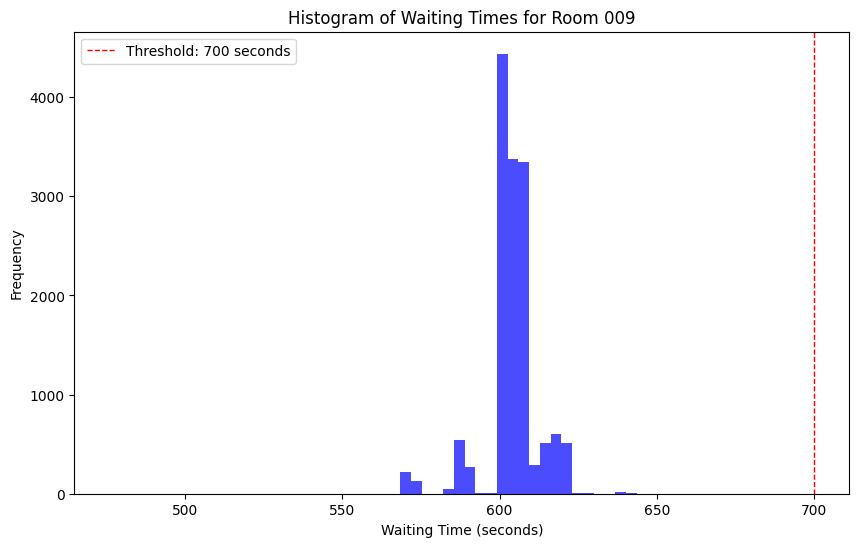

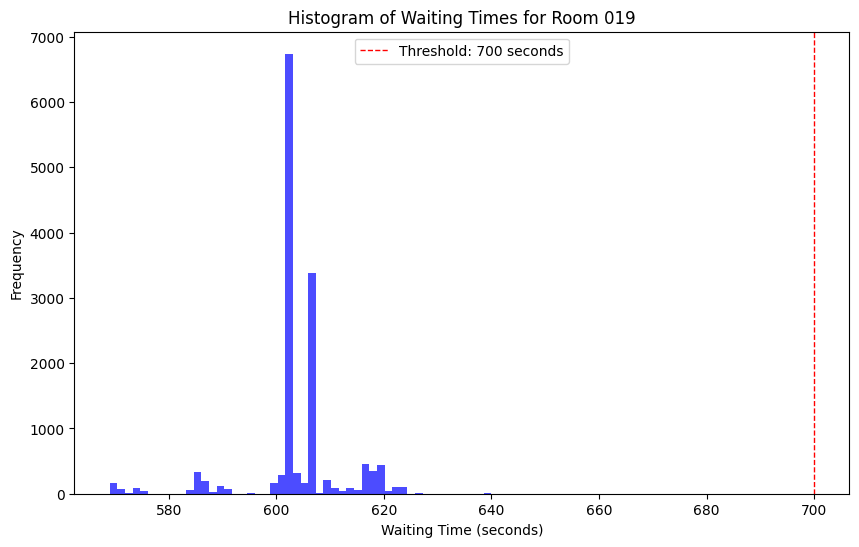

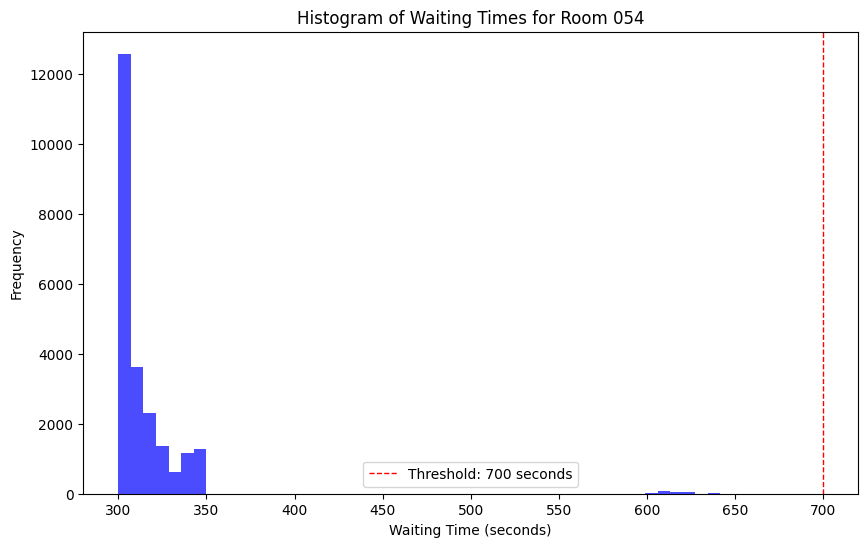

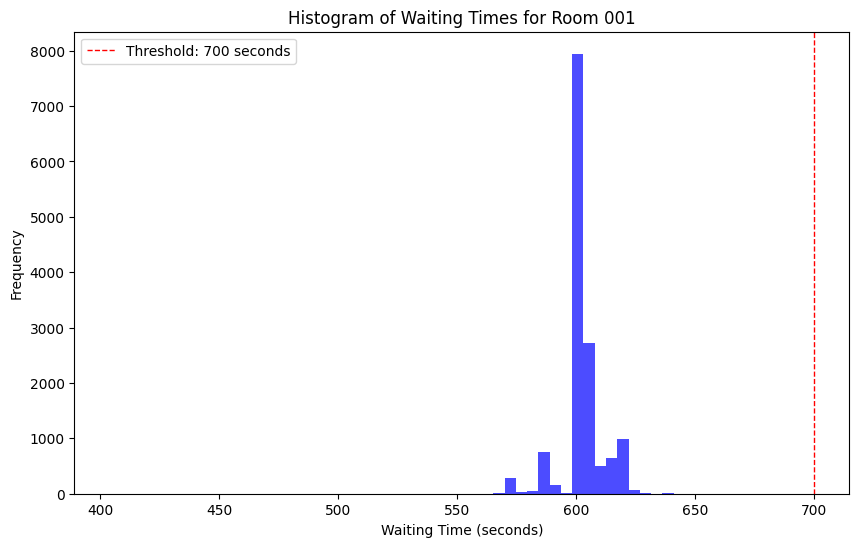

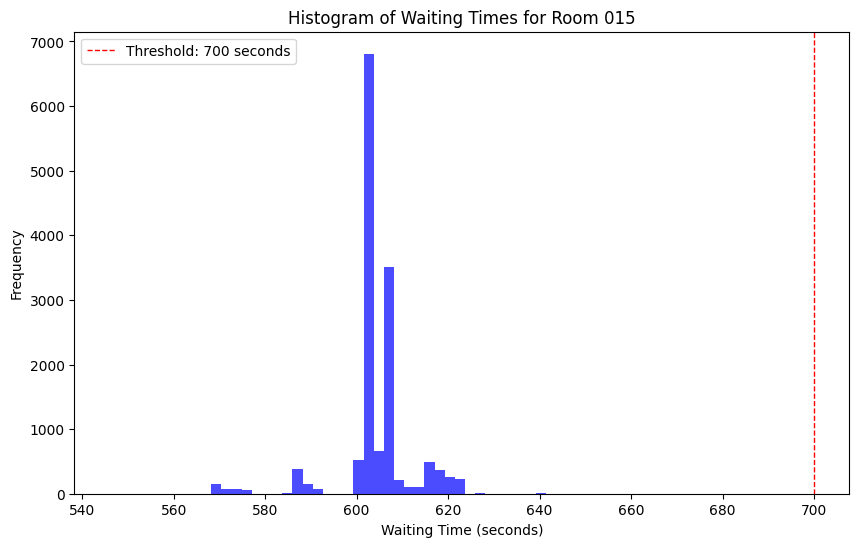

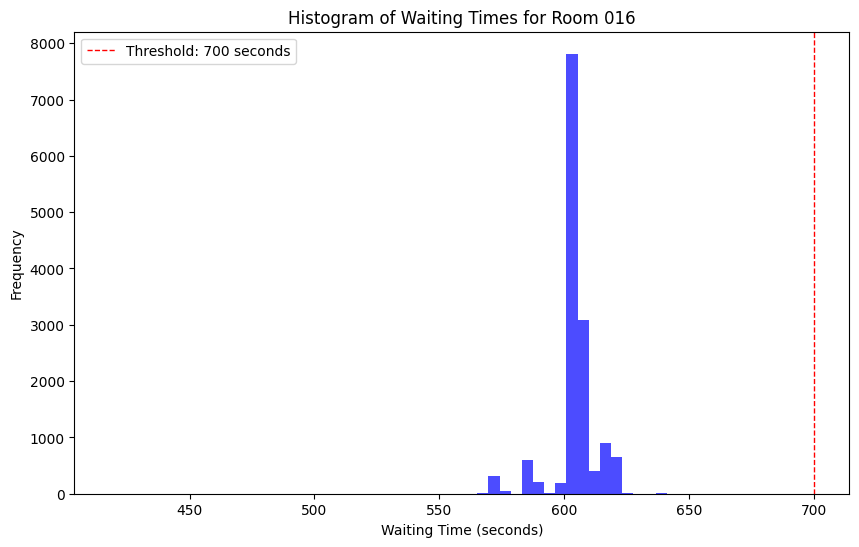

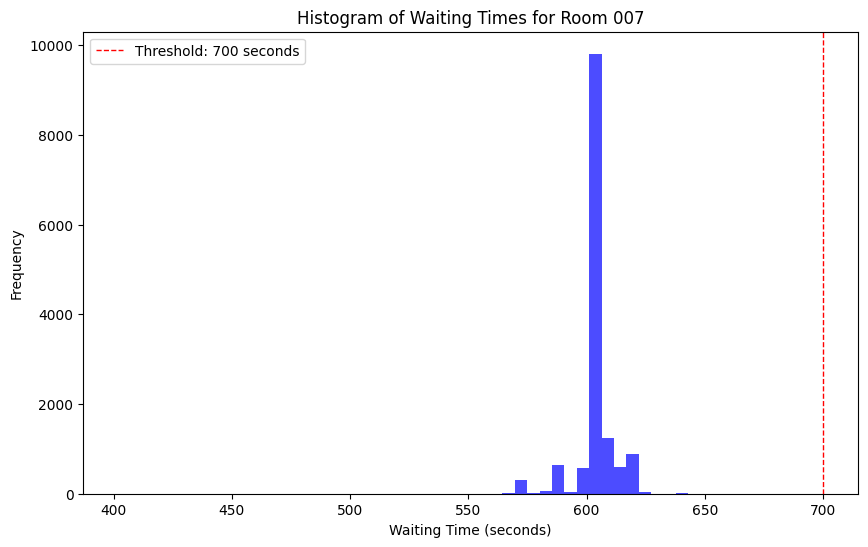

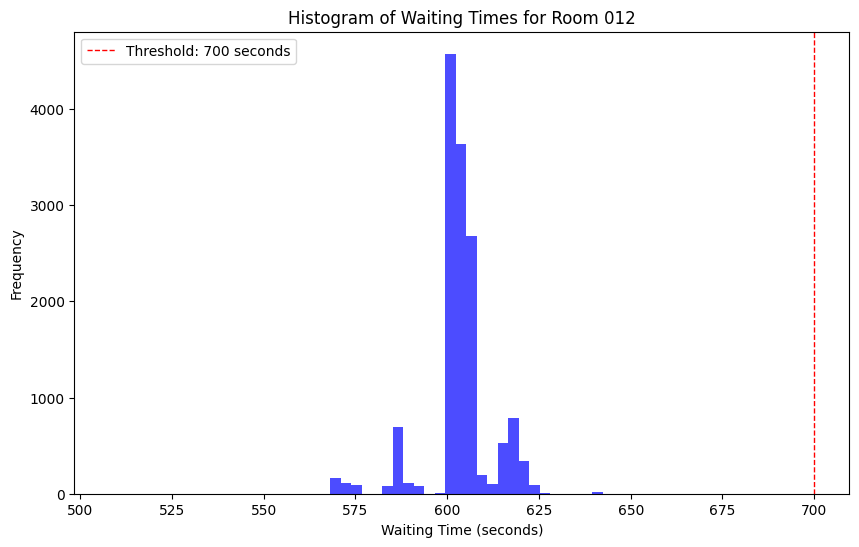

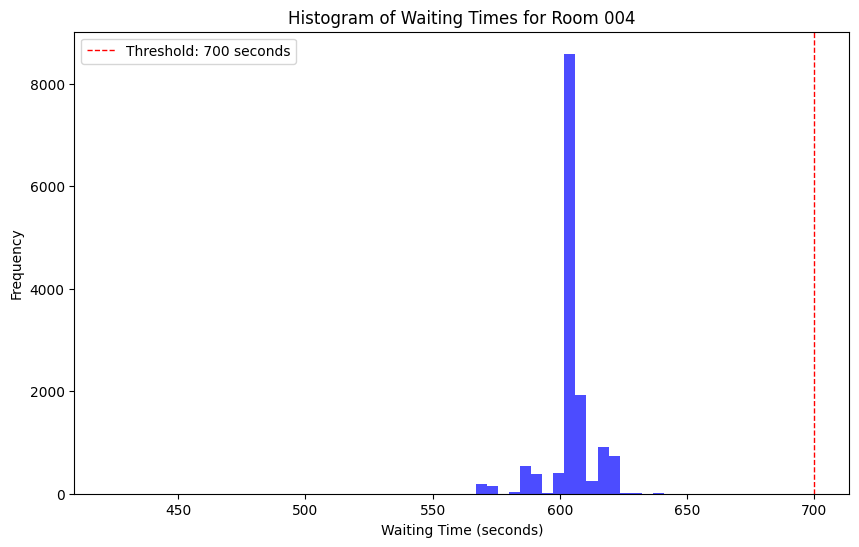

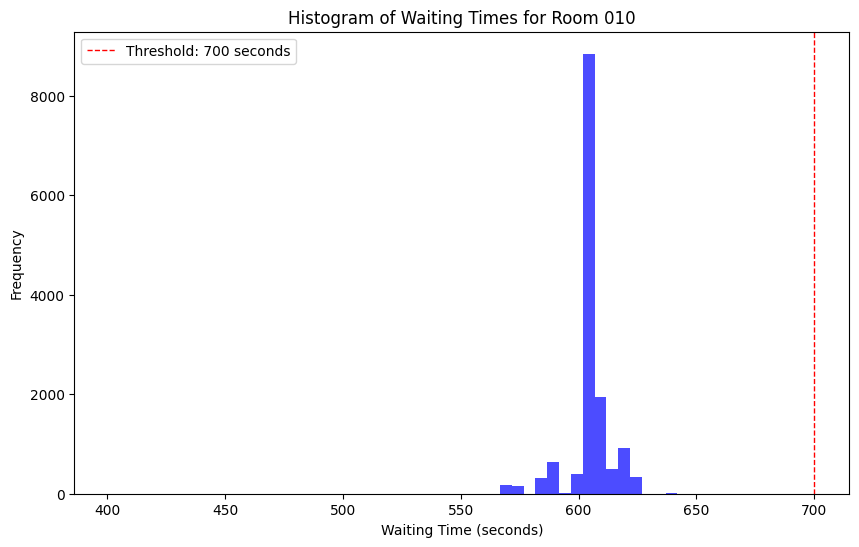

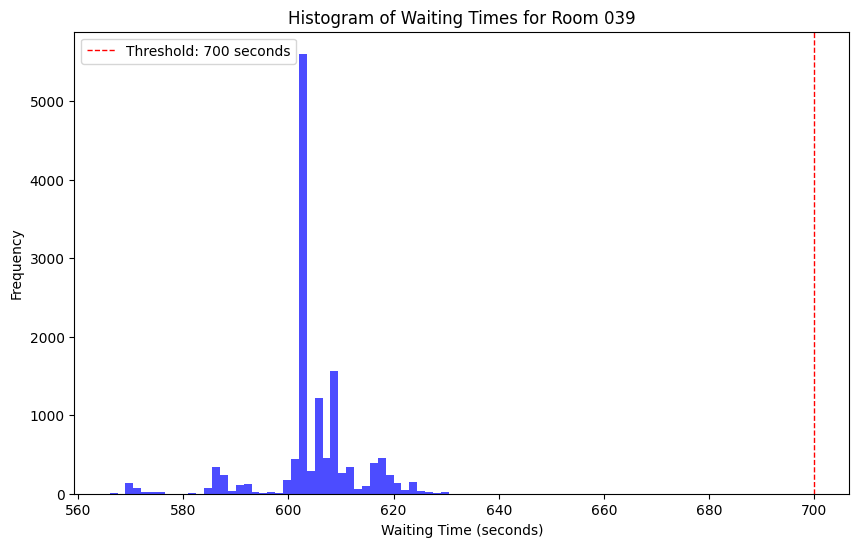

In [123]:
upper_threshold = 700 #seconds
lower_threshold = 300 #seconds
for room_name, series in df_series.items():
    waiting_time = series['datetime'].diff().dt.total_seconds() 
    #Find quantile of waiting times 
    

    #histogram of waiting times
    waiting_time_threshold = waiting_time[waiting_time <= upper_threshold]
    waiting_time_threshold = waiting_time_threshold[lower_threshold <= waiting_time]

    plt.figure(figsize=(10, 6))
    plt.hist(waiting_time_threshold.dropna(), bins=50, color='blue', alpha=0.7)
    plt.title(f"Histogram of Waiting Times for {room_name}")
    plt.xlabel("Waiting Time (seconds)")
    plt.ylabel("Frequency")
    plt.axvline(threshold, color='red', linestyle='dashed', linewidth=1, label=f'Threshold: {threshold} seconds')
    plt.legend()
    plt.show()
    

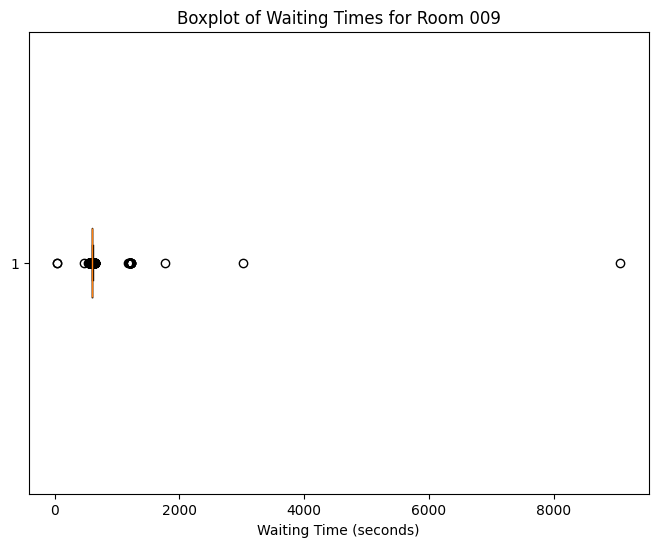

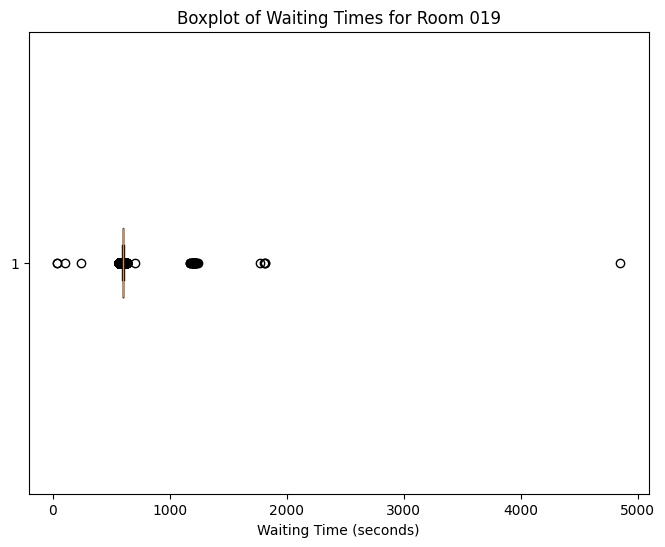

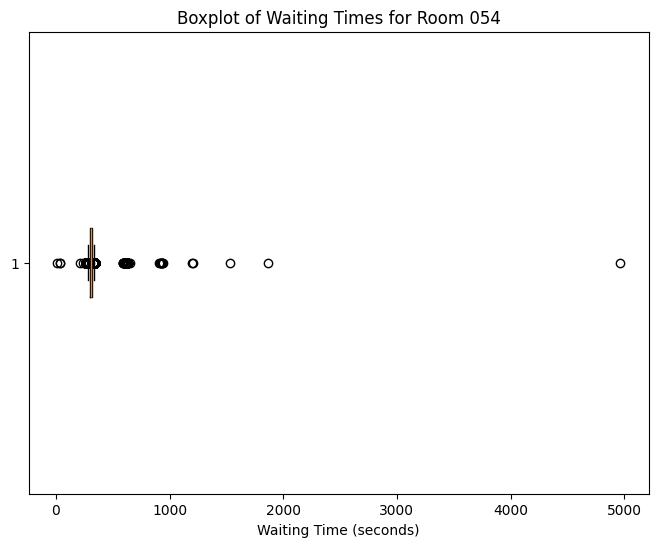

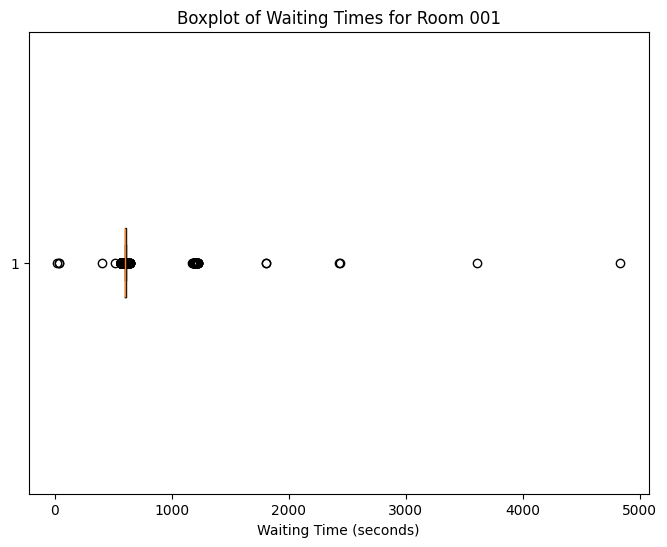

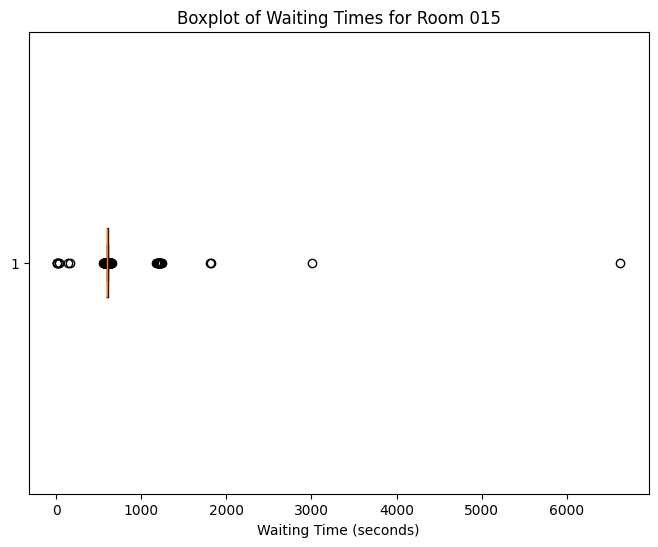

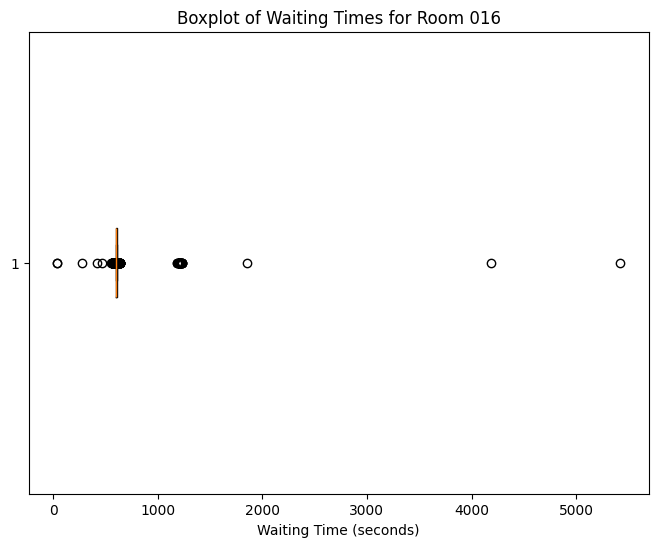

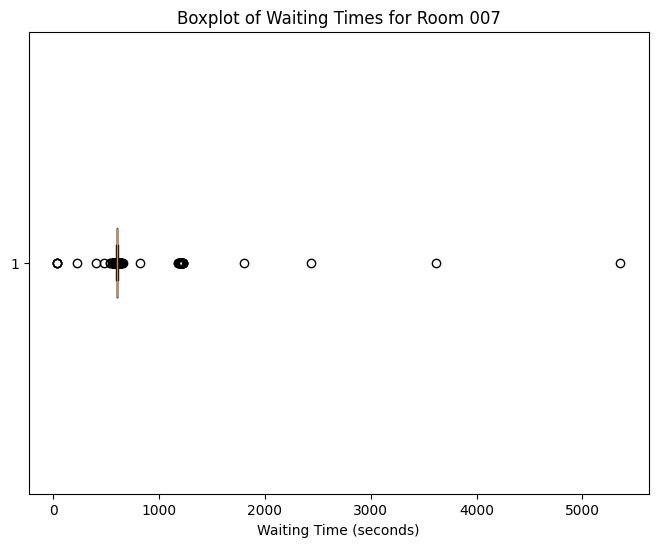

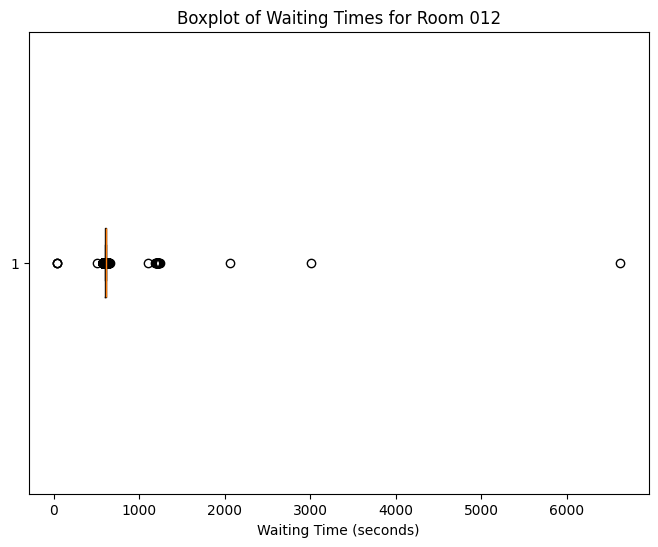

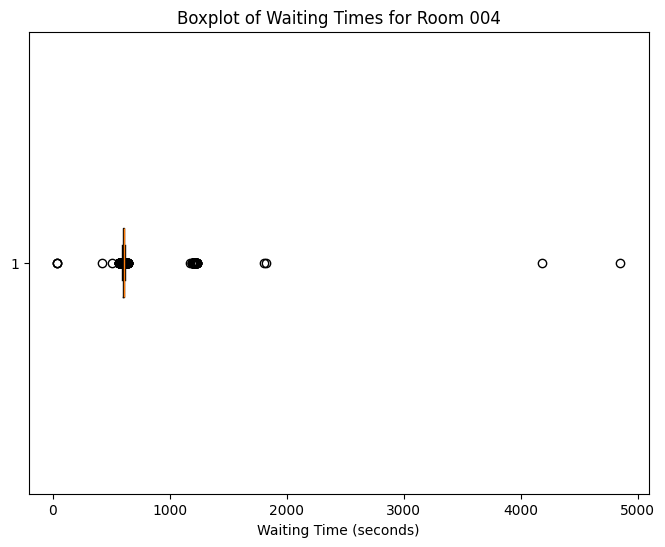

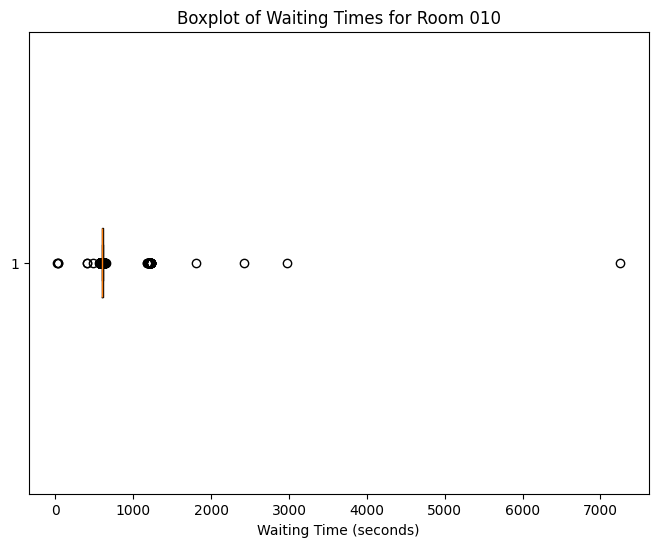

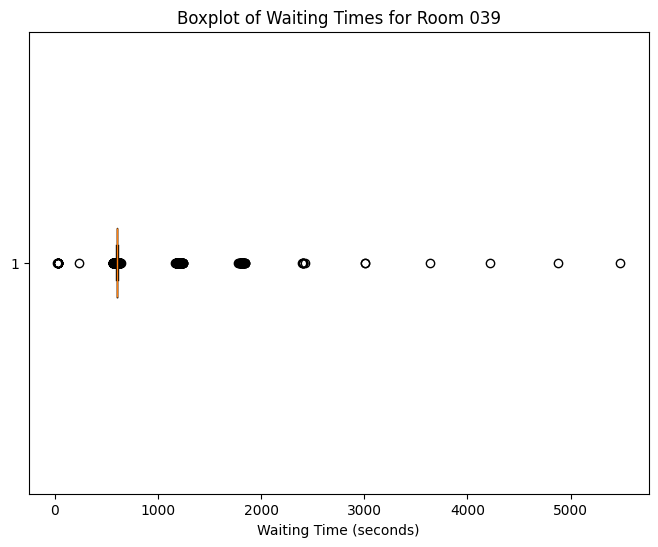

In [124]:
for room_name, series_df in df_series.items():
    # Printing boxplots of waiting times 
    waiting_time = series_df['datetime'].diff().dt.total_seconds()

    plt.figure(figsize=(8, 6))
    plt.boxplot(waiting_time.dropna(), vert=False)
    plt.title(f"Boxplot of Waiting Times for {room_name}")
    plt.xlabel("Waiting Time (seconds)")
    plt.show()

There is quite a few observations outside the 25-75% range, but the mean is very close to the median for all rooms. The waiting time is also very consistent across rooms with a mean of around 600 seconds.

This indicates that the waiting is NOT a geomtric or exponential distribution, but rather a normal distribution. Should we maybe consider a partial marov model for the waiting time?

## Summary Statistics of CO2 data

In [125]:
for room_name, series_df in df_series.items(): 
    # create summary statistics of CO2 values
    co2_values = series_df['co2'].dropna()
    summary_stats = co2_values.describe()
    print(f"Summary Statistics of CO2 Values for {room_name}:")
    print(summary_stats)

Summary Statistics of CO2 Values for Room 009:
count    14348.000000
mean       935.790424
std        551.321084
min        325.000000
25%        528.000000
50%        685.000000
75%       1219.000000
max       5651.000000
Name: co2, dtype: float64
Summary Statistics of CO2 Values for Room 019:
count    14340.000000
mean       887.373849
std        438.424399
min        355.000000
25%        531.000000
50%        727.000000
75%       1158.250000
max       5651.000000
Name: co2, dtype: float64
Summary Statistics of CO2 Values for Room 054:
count    27999.000000
mean      1048.117576
std        514.159062
min        276.000000
25%        642.000000
50%        919.000000
75%       1381.000000
max       5651.000000
Name: co2, dtype: float64
Summary Statistics of CO2 Values for Room 001:
count    14292.000000
mean       829.529177
std        517.716728
min        341.000000
25%        517.000000
50%        621.000000
75%        897.000000
max       5651.000000
Name: co2, dtype: float64
Summ

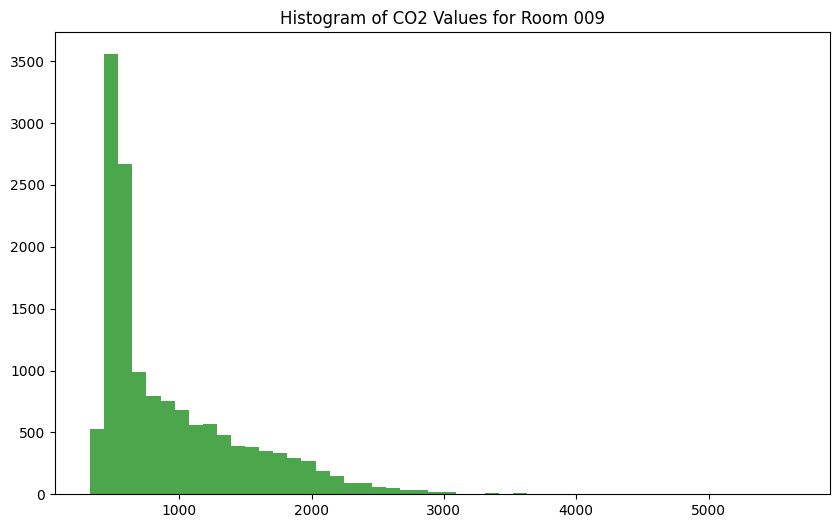

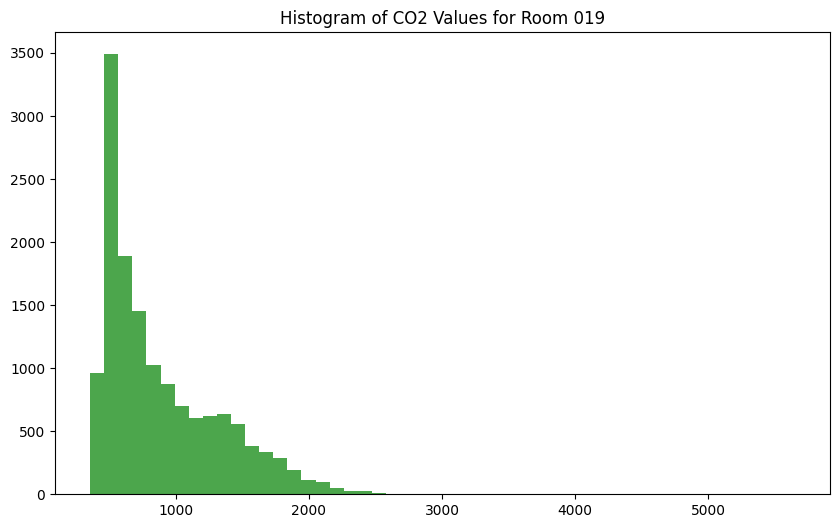

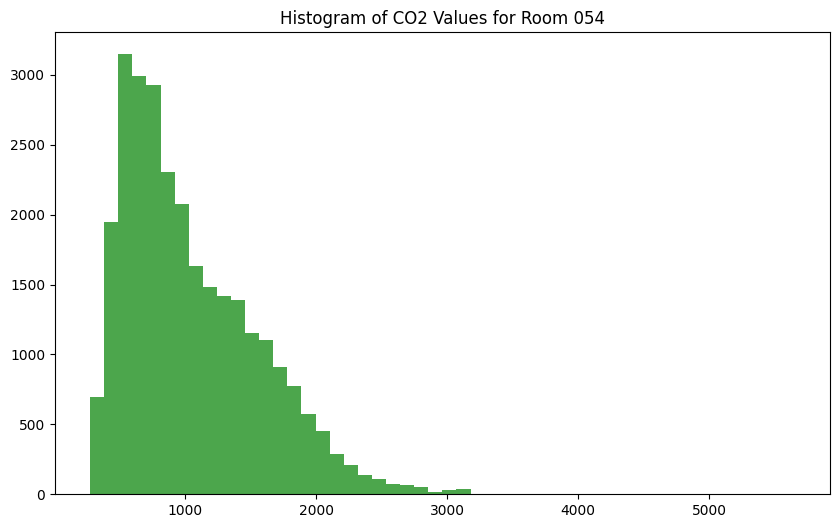

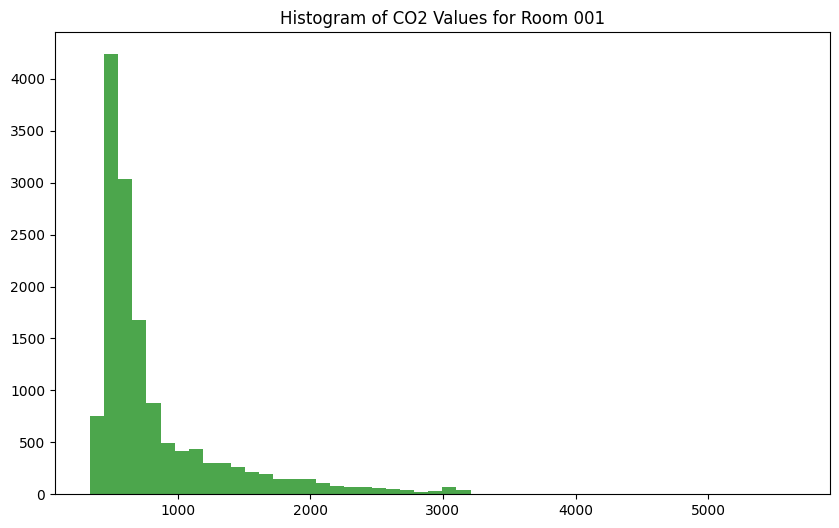

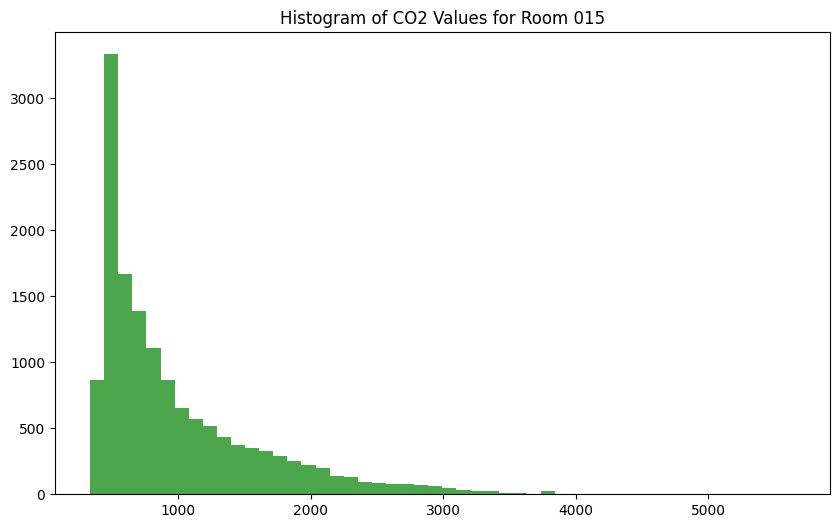

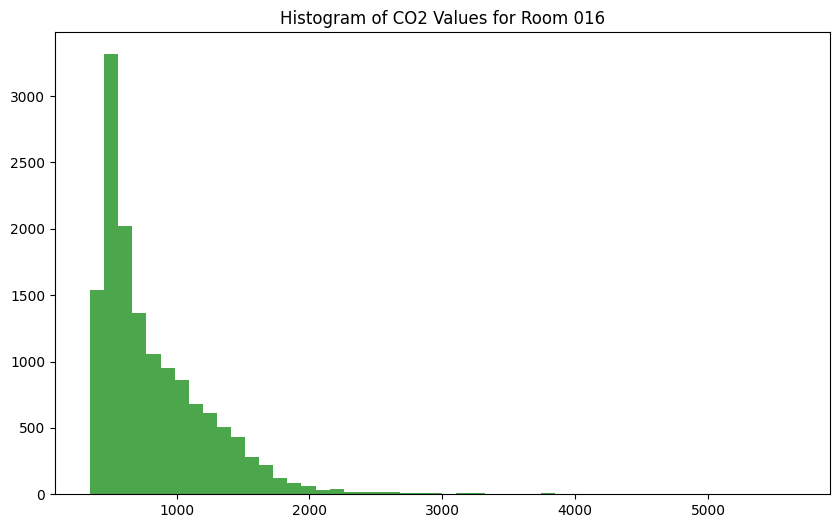

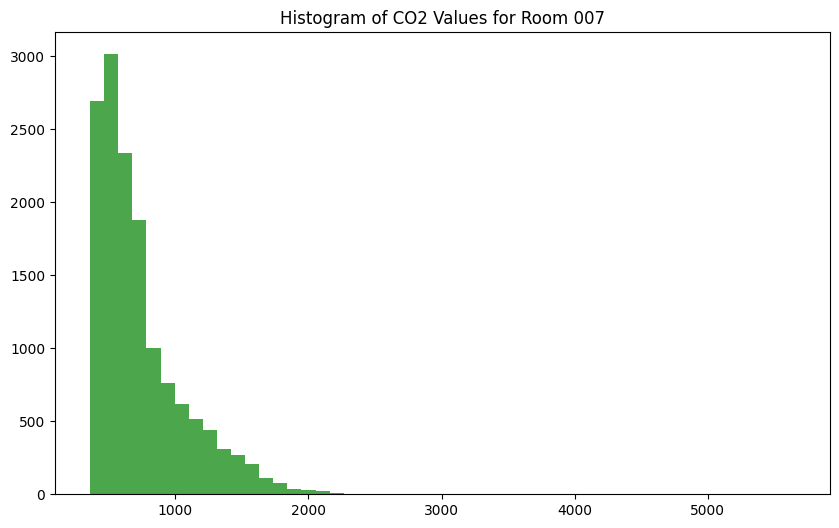

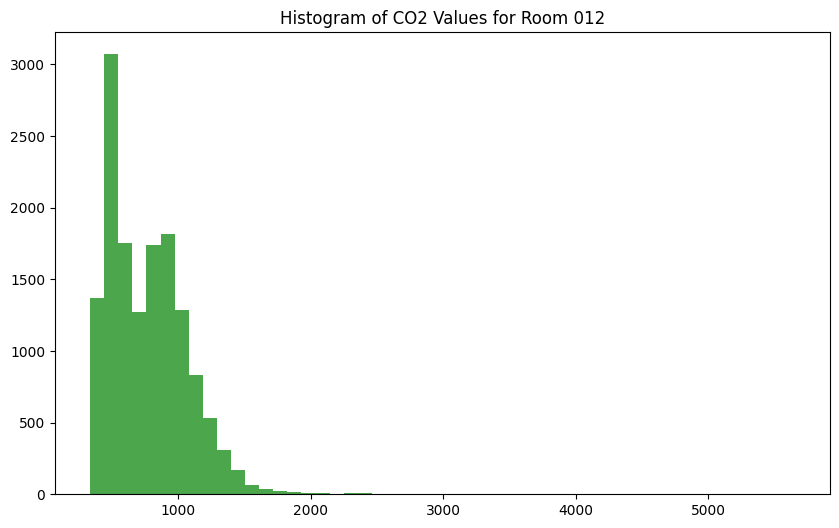

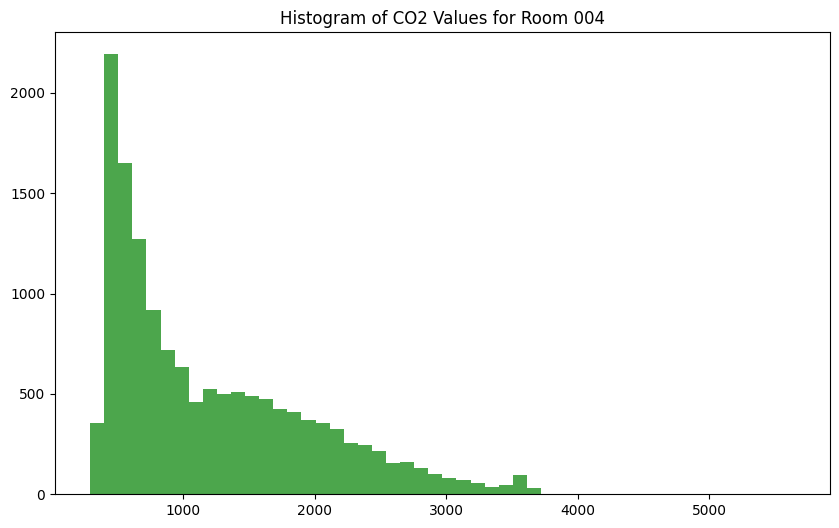

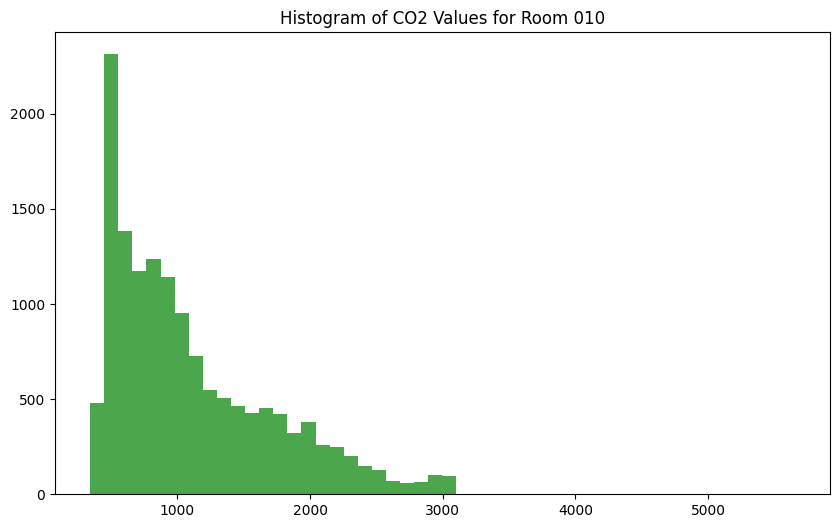

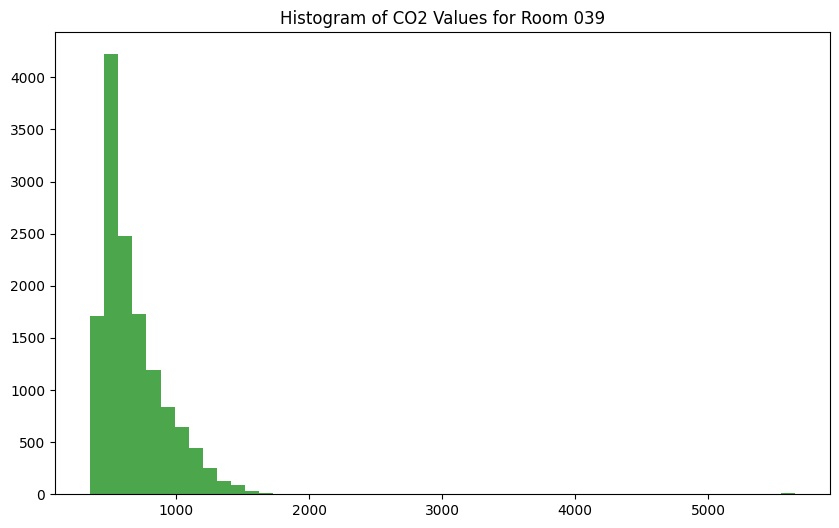

In [126]:


for room_name, series_df in df_series.items():
    # Create histogram of CO2 values
    co2_values = series_df['co2'].dropna()
    plt.figure(figsize=(10, 6))
    plt.hist(co2_values, bins=50, color='green', alpha=0.7)
    plt.title(f"Histogram of CO2 Values for {room_name}")   

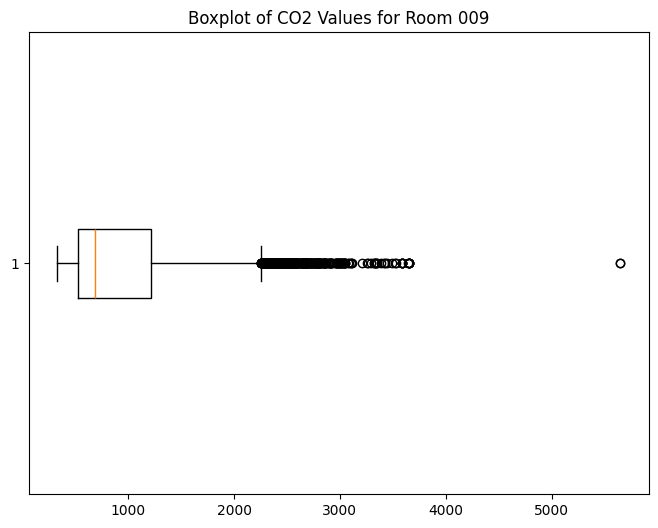

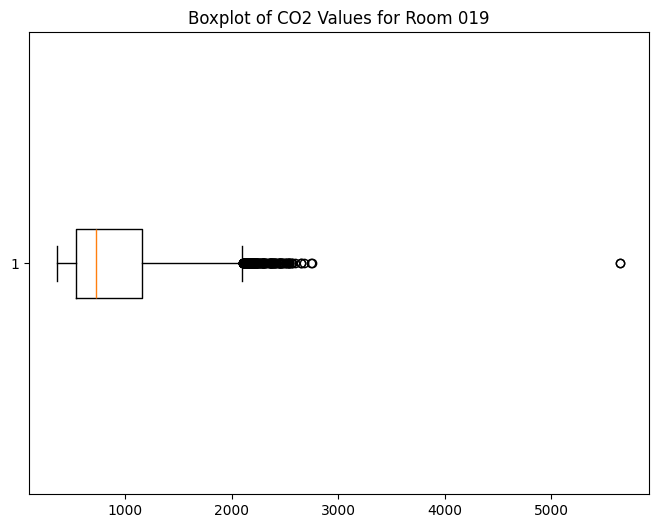

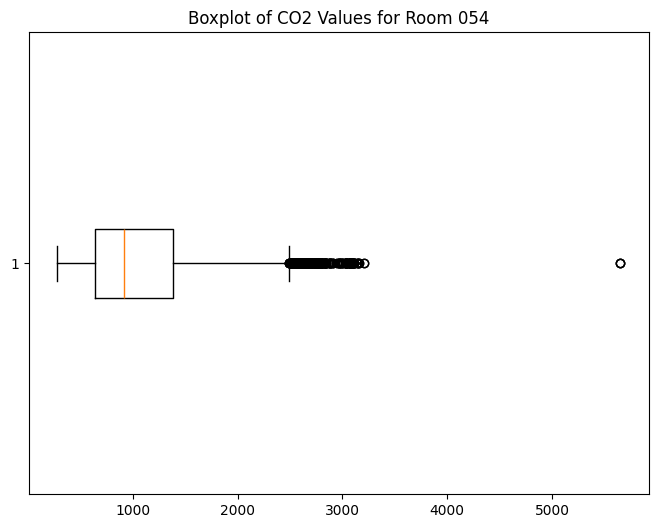

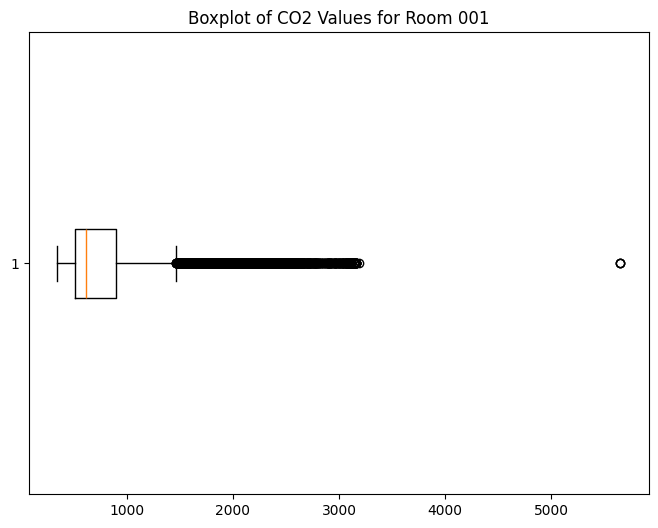

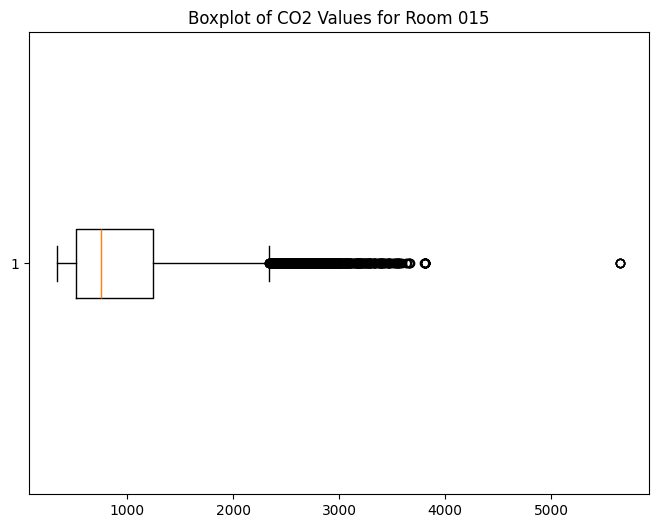

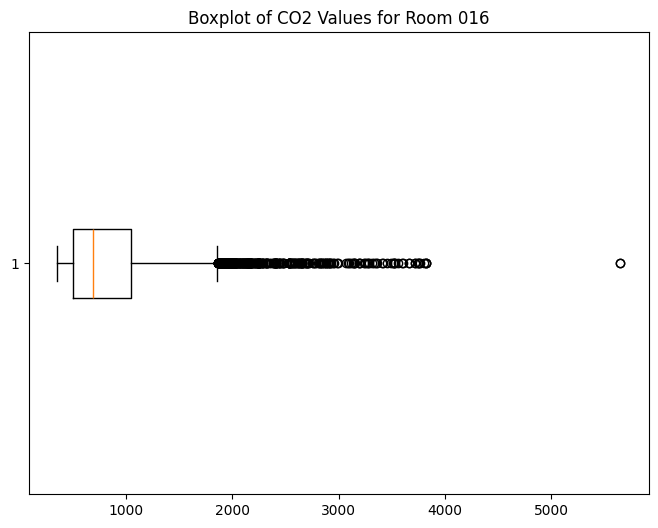

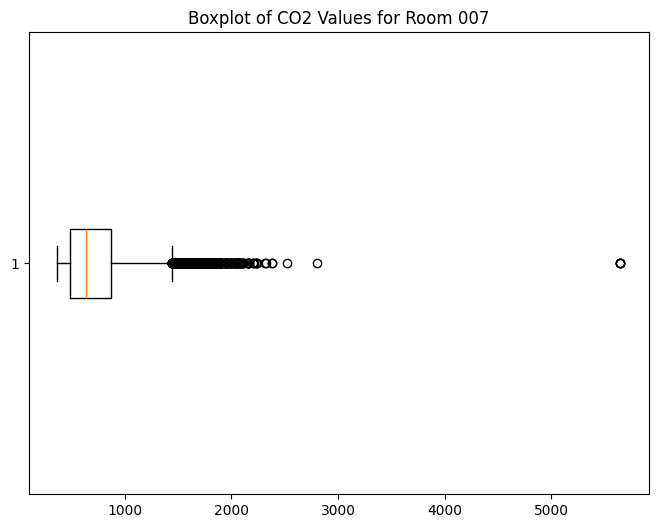

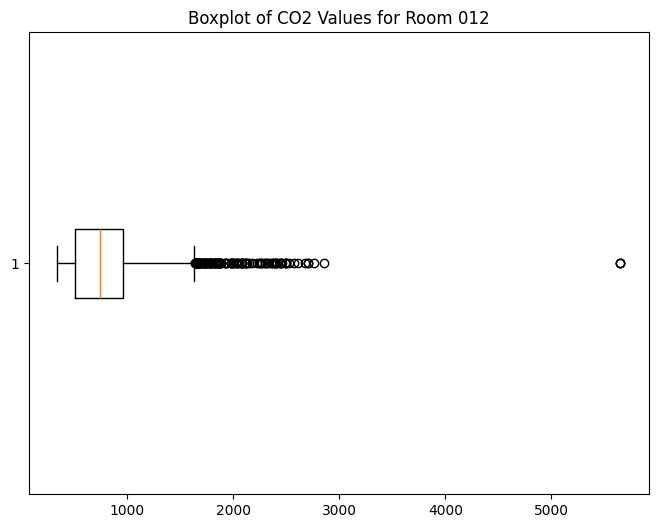

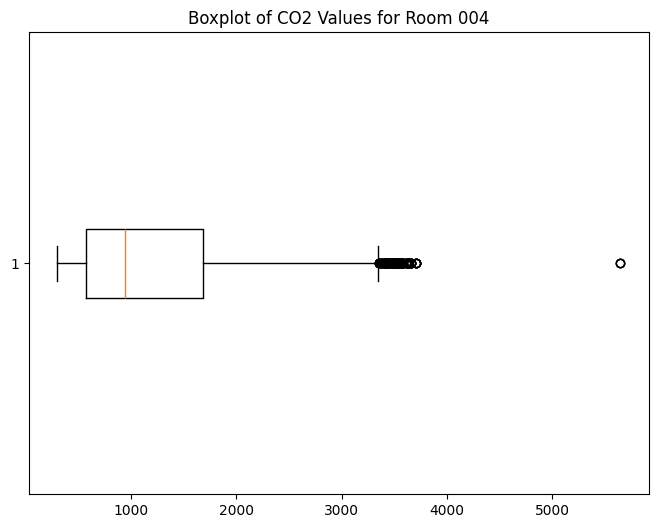

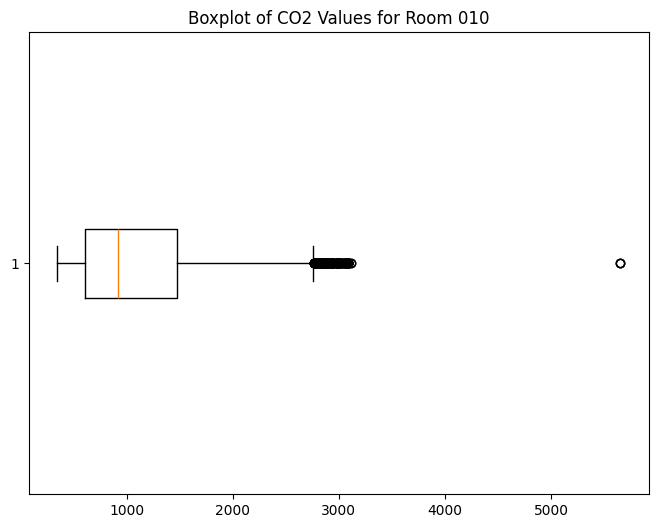

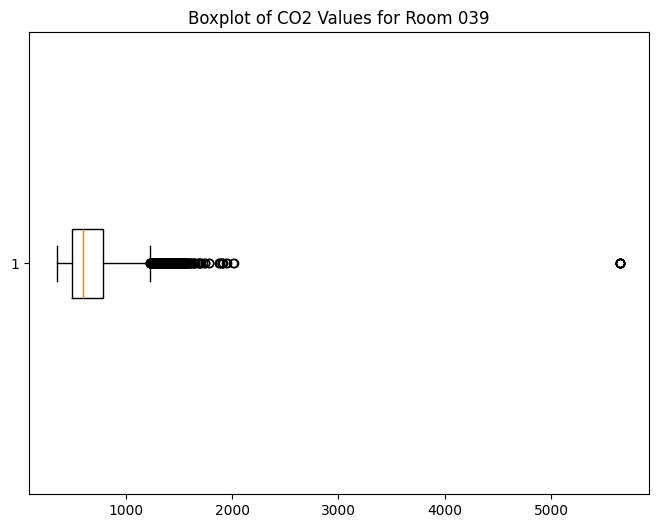

In [127]:
for room_name, series_df in df_series.items(): 
    # Create boxplots of CO2 values$
    plt.figure(figsize=(8, 6))
    plt.boxplot(series_df['co2'].dropna(), vert=False)
    plt.title(f"Boxplot of CO2 Values for {room_name}")

In [128]:
cols_to_keep = ['datetime', 'co2']
for room_name, series_df in df_series.items():
    # Remove observations where CO2 is greater than 3000
    series_df = series_df[series_df['co2'] >= 4000]
    print(f"Room: {room_name}, Remaining observations after removing CO2 > 4000: {len(series_df)}")
    print(series_df[cols_to_keep])


Room: Room 009, Remaining observations after removing CO2 > 4000: 2
                 datetime     co2
27736 2024-01-12 13:42:45  5651.0
27750 2024-01-12 14:03:01  5651.0
Room: Room 019, Remaining observations after removing CO2 > 4000: 2
                 datetime     co2
31088 2024-01-12 13:20:41  5651.0
31092 2024-01-12 13:50:59  5651.0
Room: Room 054, Remaining observations after removing CO2 > 4000: 3
                 datetime     co2
51324 2024-01-12 13:05:58  5651.0
51325 2024-01-12 13:06:06  5651.0
51326 2024-01-12 13:06:39  5651.0
Room: Room 001, Remaining observations after removing CO2 > 4000: 3
                 datetime     co2
17294 2024-01-12 13:13:20  5651.0
17295 2024-01-12 13:14:00  5651.0
17296 2024-01-12 13:14:33  5651.0
Room: Room 015, Remaining observations after removing CO2 > 4000: 5
                 datetime     co2
17402 2024-01-12 14:27:18  5651.0
17404 2024-01-12 14:36:52  5651.0
17406 2024-01-12 14:47:14  5651.0
17407 2024-01-12 14:47:49  5651.0
17412 2024-01-

Because we have severel obs with the exavt same CO2 value on the exact same timestamp, we will first remove duplicates and then look at the summary statistics of the CO2 data.

In [129]:
df_series_cleaned = {}

for room_name, series_df in df_series.items():
    # Remove duplicates based on 'datetime' and 'co2' columns
    series_df_cleaned = series_df[series_df["co2"] <= 4000]
    series_df_cleaned = series_df_cleaned[series_df_cleaned["co2"].notna()]
    series_df_cleaned = series_df_cleaned.drop_duplicates(subset=['datetime', 'co2'])

    # Store the cleaned DataFrame in the new dictionary
    df_series_cleaned[room_name] = series_df_cleaned

    print(f"Room: {room_name}, Removed {len(series_df)- len(series_df_cleaned)} obs")

Room: Room 009, Removed 2 obs
Room: Room 019, Removed 2 obs
Room: Room 054, Removed 3 obs
Room: Room 001, Removed 3 obs
Room: Room 015, Removed 5 obs
Room: Room 016, Removed 2 obs
Room: Room 007, Removed 4 obs
Room: Room 012, Removed 3 obs
Room: Room 004, Removed 3 obs
Room: Room 010, Removed 3 obs
Room: Room 039, Removed 12 obs


## Checking for autocorrelation

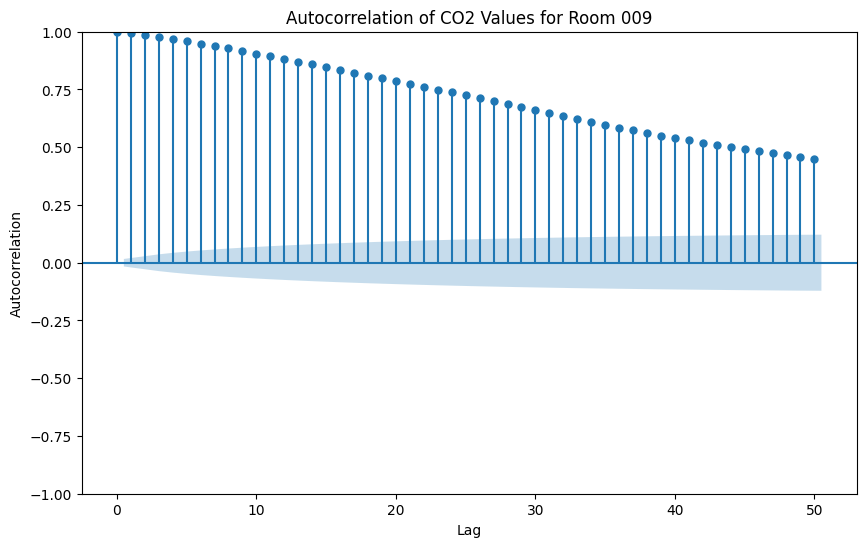

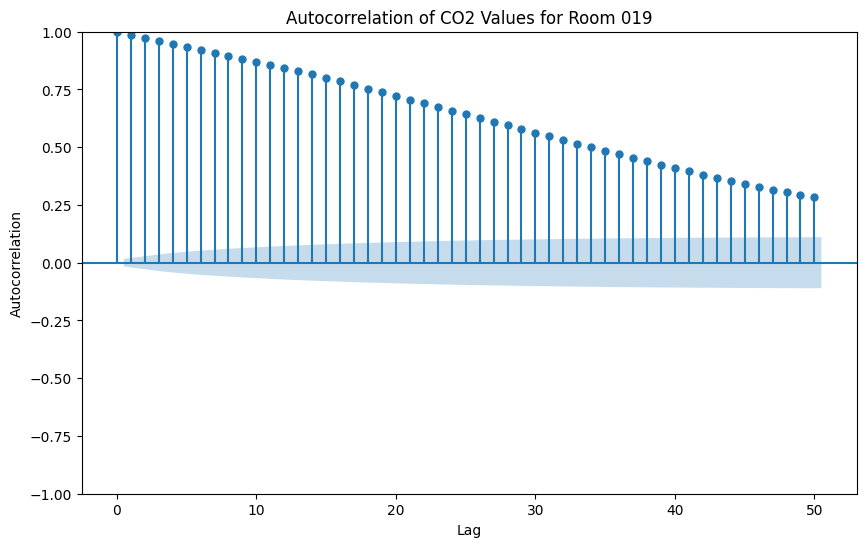

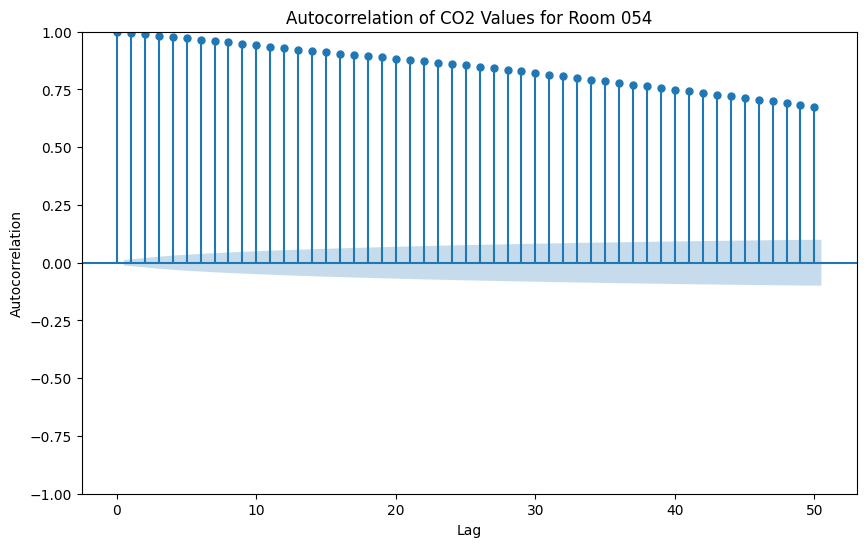

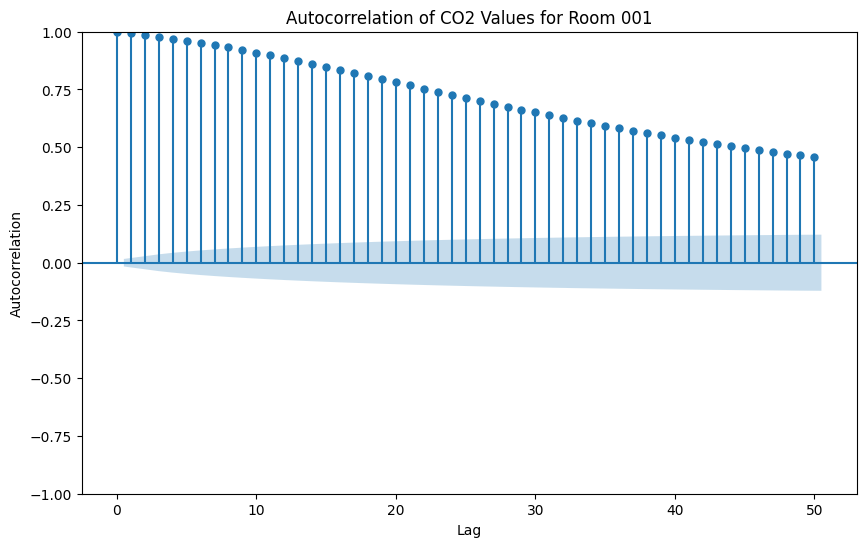

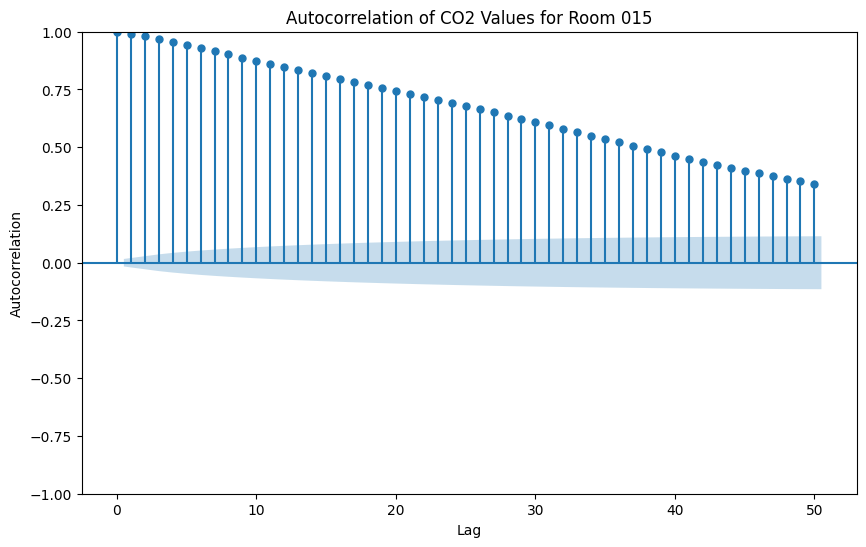

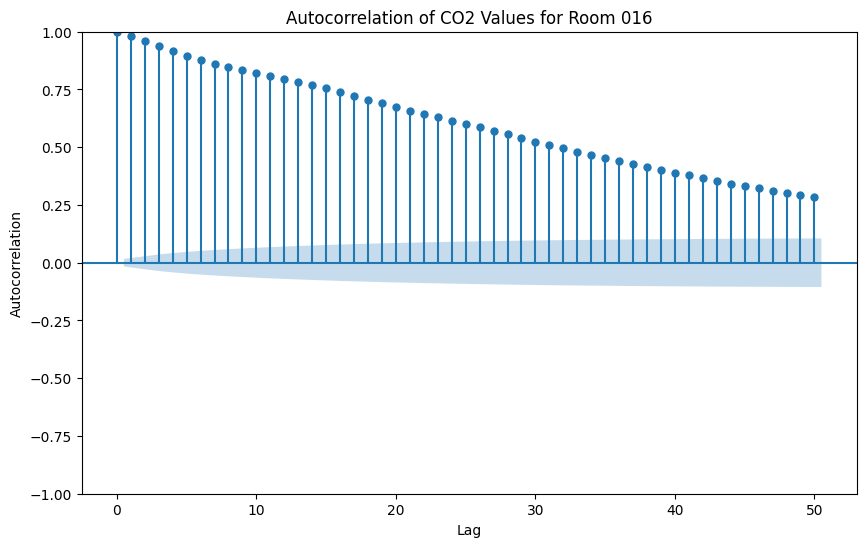

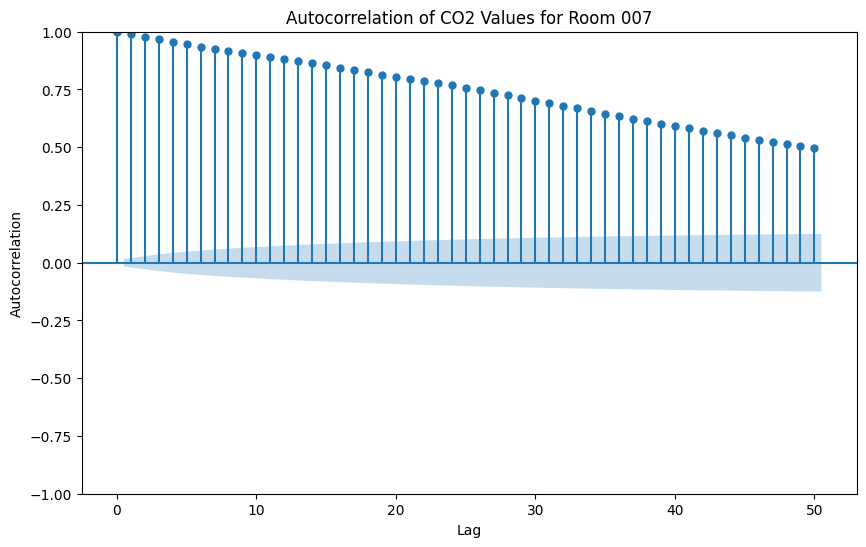

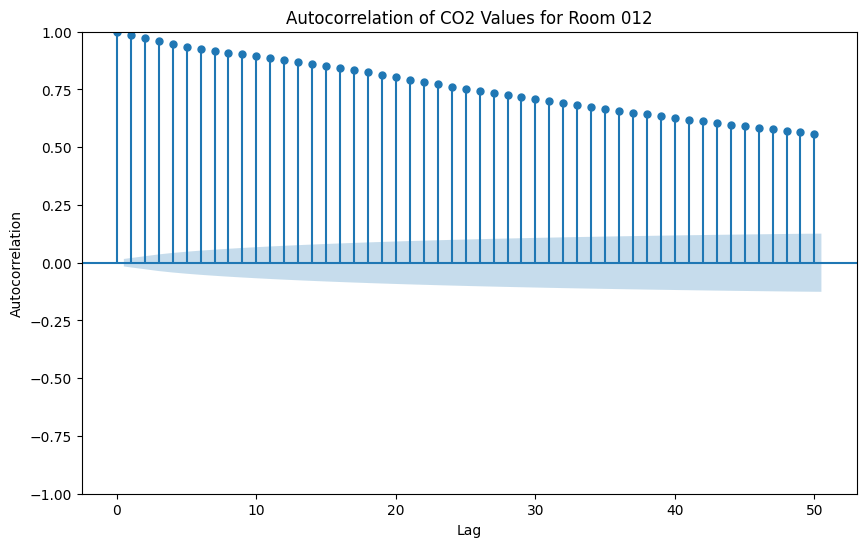

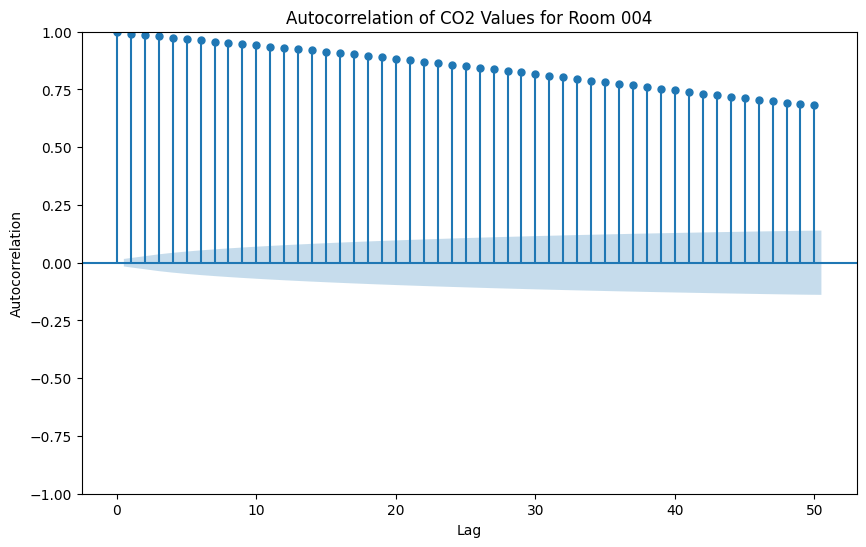

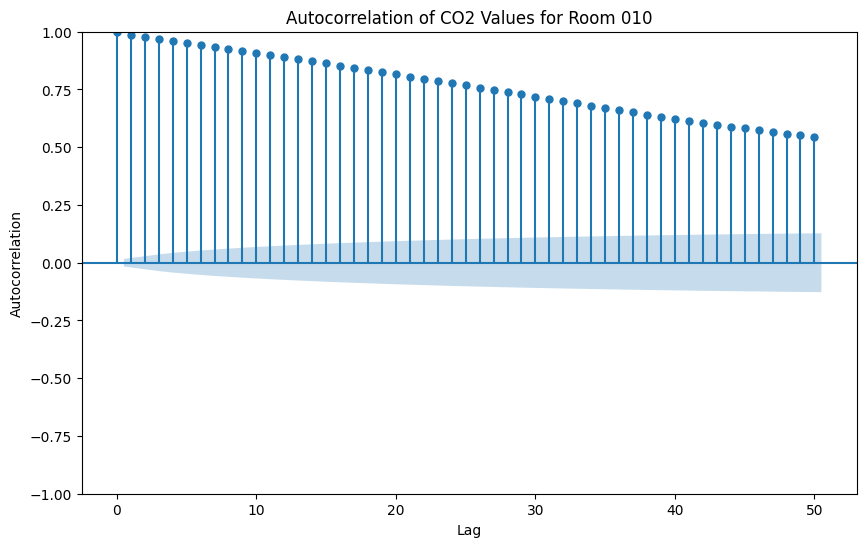

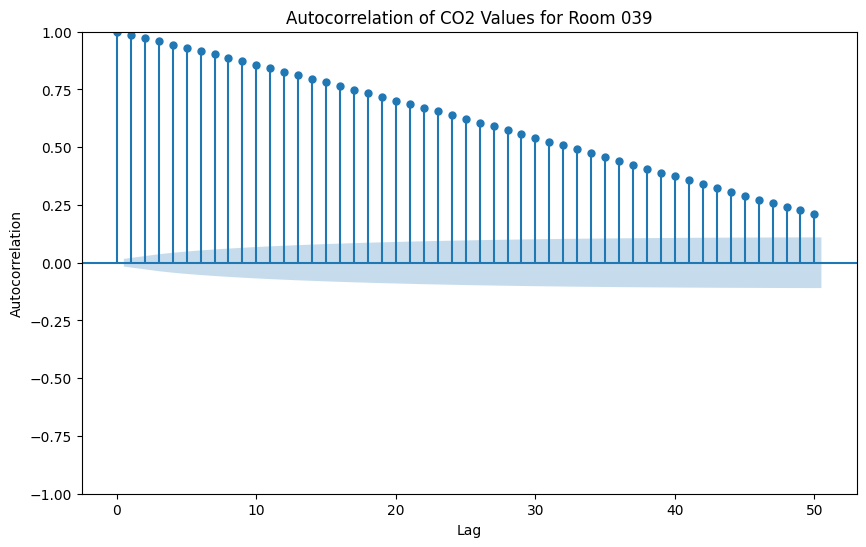

In [ ]:
#Plotting autocorrelation plot
for room_name, series_df in df_series_cleaned.items():
    co2_values = series_df['co2']
    plt.figure(figsize=(10, 6))
    sm.graphics.tsa.plot_acf(co2_values, lags=50, ax=plt.gca())
    plt.title(f"Autocorrelation of CO2 Values for {room_name}")
    plt.xlabel("Lag")
    plt.ylabel("Autocorrelation")
    plt.show()

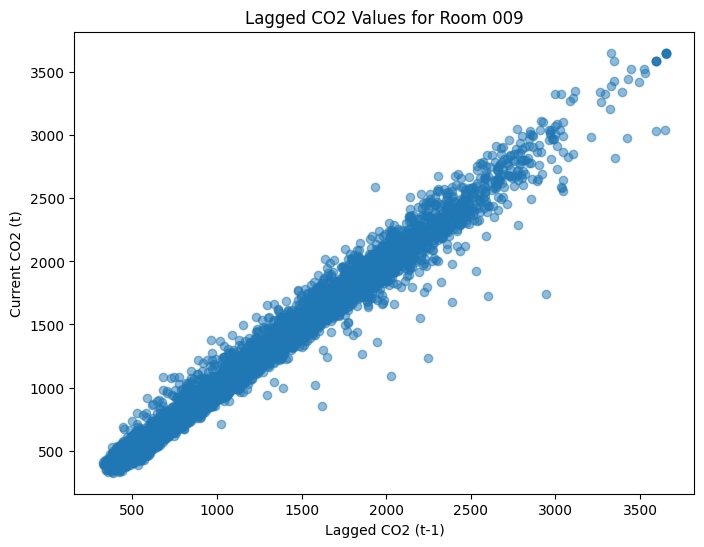

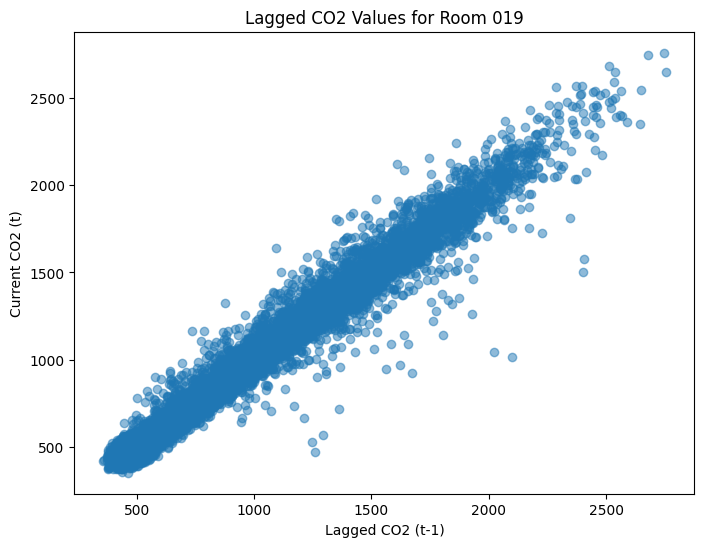

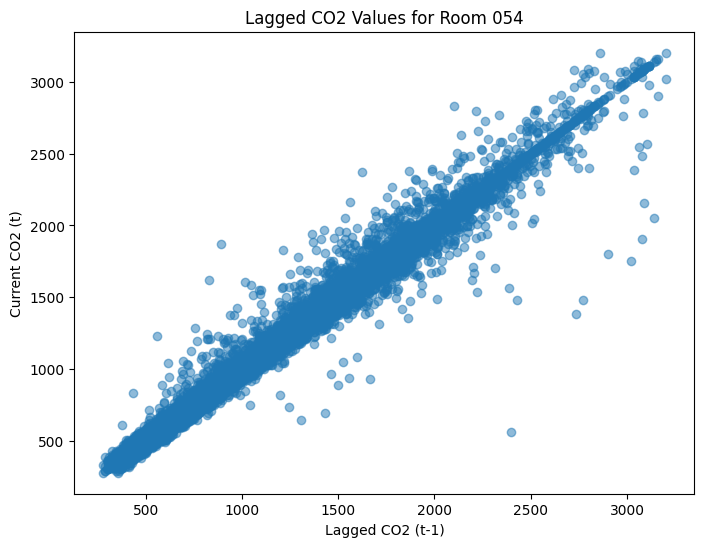

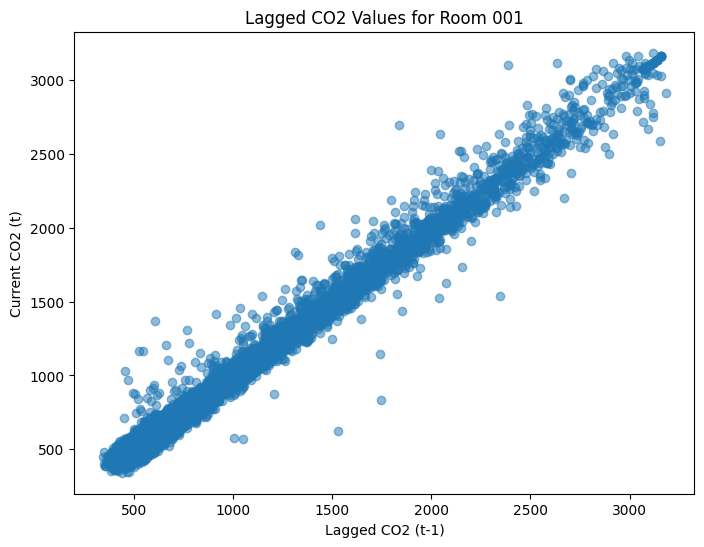

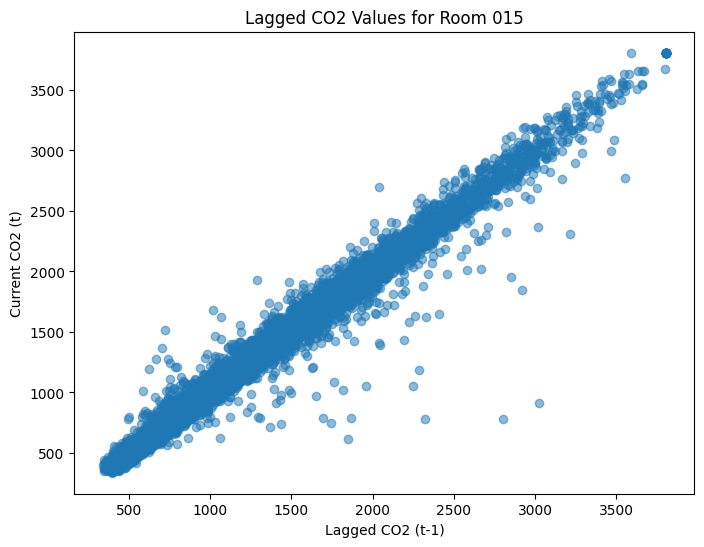

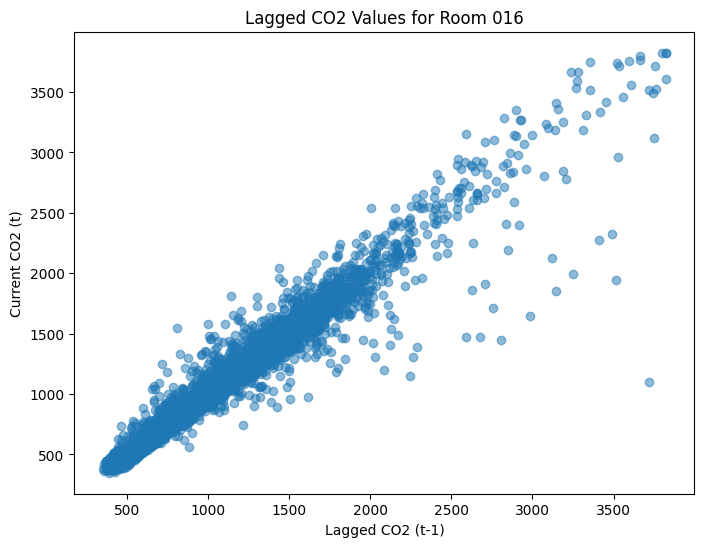

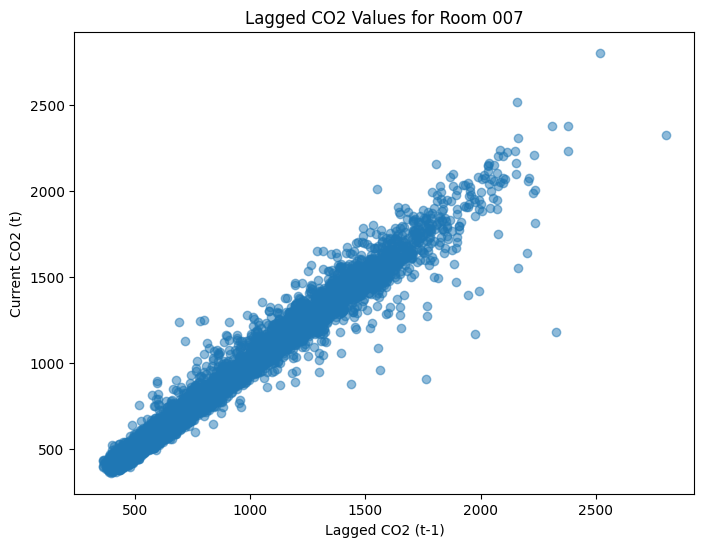

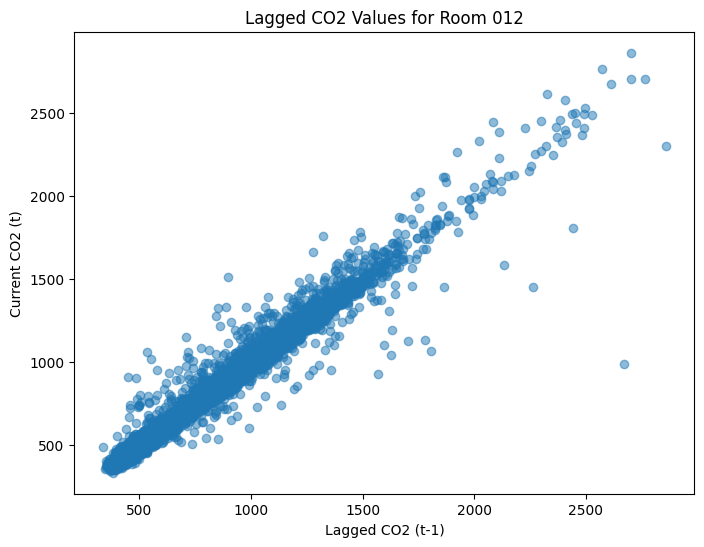

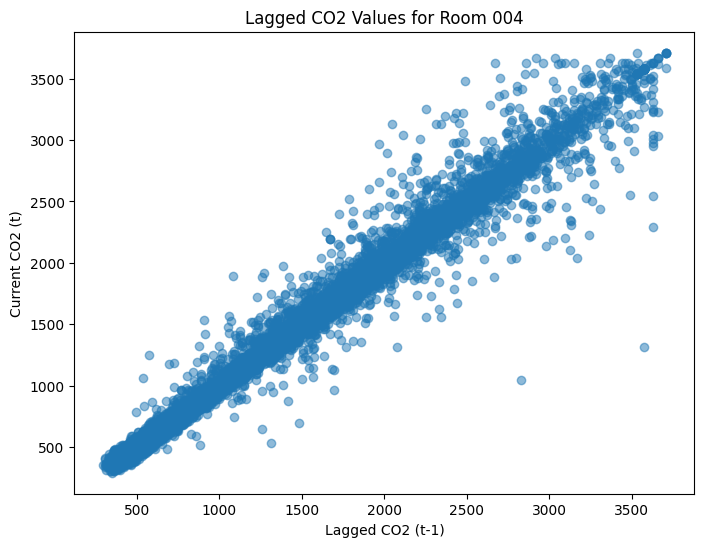

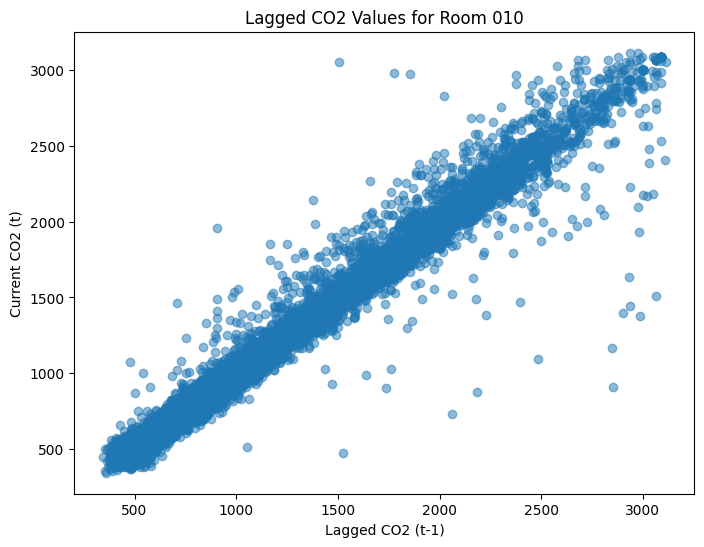

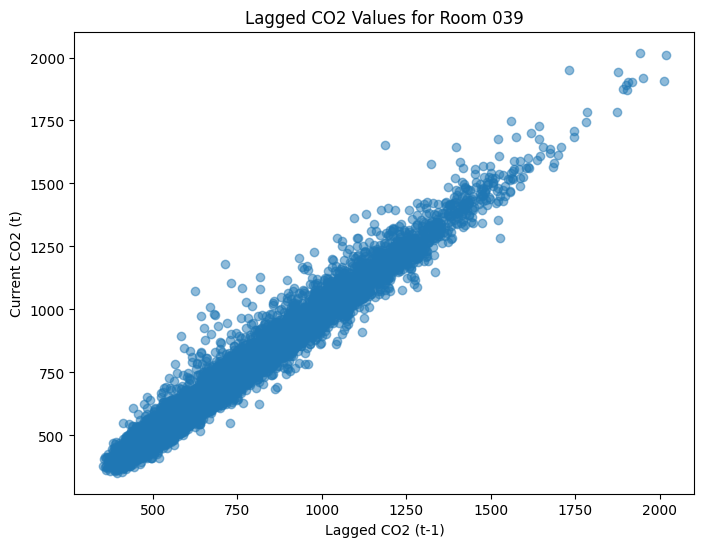

In [132]:
#plotting lagged 1 vs current 

for room_name, series_df in df_series_cleaned.items():
    plt.figure(figsize=(8, 6))
    plt.scatter(series_df['co2'].shift(1), series_df['co2'], alpha=0.5)
    plt.title(f"Lagged CO2 Values for {room_name}")
    plt.xlabel("Lagged CO2 (t-1)")
    plt.ylabel("Current CO2 (t)")
    plt.show()

In [137]:
import numpy as np
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.stattools import acf

SECONDS_PER_OBS = 600


for room_name, series_df in df_series_cleaned.items():
    data = series_df['co2'].values  # your 1D array of residuals or a time series
    result = acorr_ljungbox(data, lags=[2000], return_df=True)

    print(f"Ljung-Box test results for {room_name}:")
    print(result)
    print()

Ljung-Box test results for Room 009:
           lb_stat  lb_pvalue
2000  1.305408e+06        0.0

Ljung-Box test results for Room 019:
           lb_stat  lb_pvalue
2000  1.359706e+06        0.0

Ljung-Box test results for Room 054:
           lb_stat  lb_pvalue
2000  3.788332e+06        0.0

Ljung-Box test results for Room 001:
           lb_stat  lb_pvalue
2000  684300.96919        0.0

Ljung-Box test results for Room 015:
           lb_stat  lb_pvalue
2000  1.332180e+06        0.0

Ljung-Box test results for Room 016:
           lb_stat  lb_pvalue
2000  907743.50371        0.0

Ljung-Box test results for Room 007:
            lb_stat  lb_pvalue
2000  911155.652372        0.0

Ljung-Box test results for Room 012:
           lb_stat  lb_pvalue
2000  1.022666e+06        0.0

Ljung-Box test results for Room 004:
           lb_stat  lb_pvalue
2000  1.658010e+06        0.0

Ljung-Box test results for Room 010:
           lb_stat  lb_pvalue
2000  1.060995e+06        0.0

Ljung-Box test res

In [139]:
from statsmodels.tsa.stattools import pacf
import numpy as np

nlags = 50  # pick something reasonable for your sampling rate


for room_name, series_df in df_series_cleaned.items():
    data = series_df['co2'].values  # your 1D array of residuals or a time series
    pacf_vals = pacf(data, nlags=nlags, method='ywadjusted')

    # 95% confidence bound under the null of "no partial autocorrelation"
    n = len(data)
    conf_bound = 1.96 / np.sqrt(n)
    # Find the last lag where PACF is still significant
    significant_lags = np.where(np.abs(pacf_vals) > conf_bound)[0]
    last_significant = significant_lags.max() if len(significant_lags) > 0 else 0
    print(f"Room: {room_name}, Last significant lag: {last_significant}")

Room: Room 009, Last significant lag: 28
Room: Room 019, Last significant lag: 38
Room: Room 054, Last significant lag: 47
Room: Room 001, Last significant lag: 41
Room: Room 015, Last significant lag: 36
Room: Room 016, Last significant lag: 29
Room: Room 007, Last significant lag: 33
Room: Room 012, Last significant lag: 45
Room: Room 004, Last significant lag: 42
Room: Room 010, Last significant lag: 39
Room: Room 039, Last significant lag: 41


Room: Room 009, Gradient of CO2 values:


/Users/madshaakonsson/Desktop/7-semester/hmm-modelling/.venv/lib/python3.11/site-packages/numpy/lib/_function_base_impl.py:1290: RuntimeWarning: divide by zero encountered in divide
  a = -(dx2)/(dx1 * (dx1 + dx2))
/Users/madshaakonsson/Desktop/7-semester/hmm-modelling/.venv/lib/python3.11/site-packages/numpy/lib/_function_base_impl.py:1290: RuntimeWarning: invalid value encountered in divide
  a = -(dx2)/(dx1 * (dx1 + dx2))
/Users/madshaakonsson/Desktop/7-semester/hmm-modelling/.venv/lib/python3.11/site-packages/numpy/lib/_function_base_impl.py:1291: RuntimeWarning: divide by zero encountered in divide
  b = (dx2 - dx1) / (dx1 * dx2)
/Users/madshaakonsson/Desktop/7-semester/hmm-modelling/.venv/lib/python3.11/site-packages/numpy/lib/_function_base_impl.py:1291: RuntimeWarning: invalid value encountered in divide
  b = (dx2 - dx1) / (dx1 * dx2)
/Users/madshaakonsson/Desktop/7-semester/hmm-modelling/.venv/lib/python3.11/site-packages/numpy/lib/_function_base_impl.py:1292: RuntimeWarning:

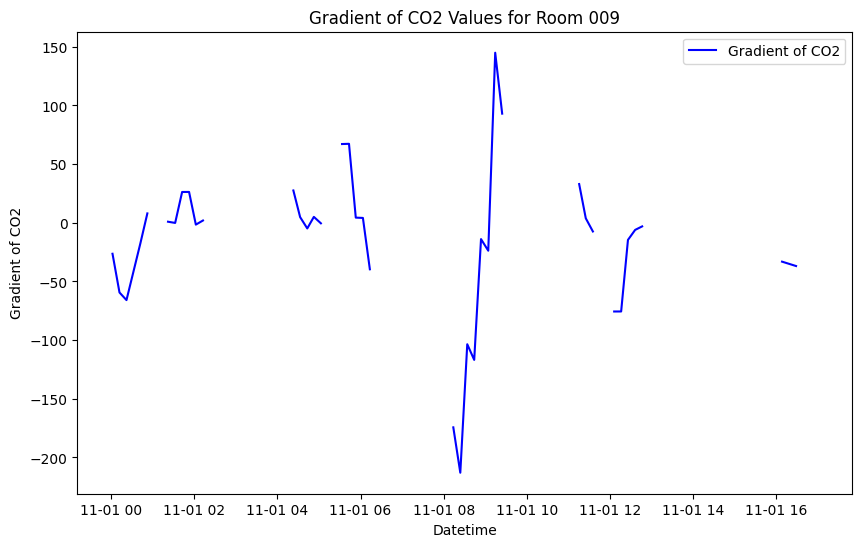

Room: Room 019, Gradient of CO2 values:


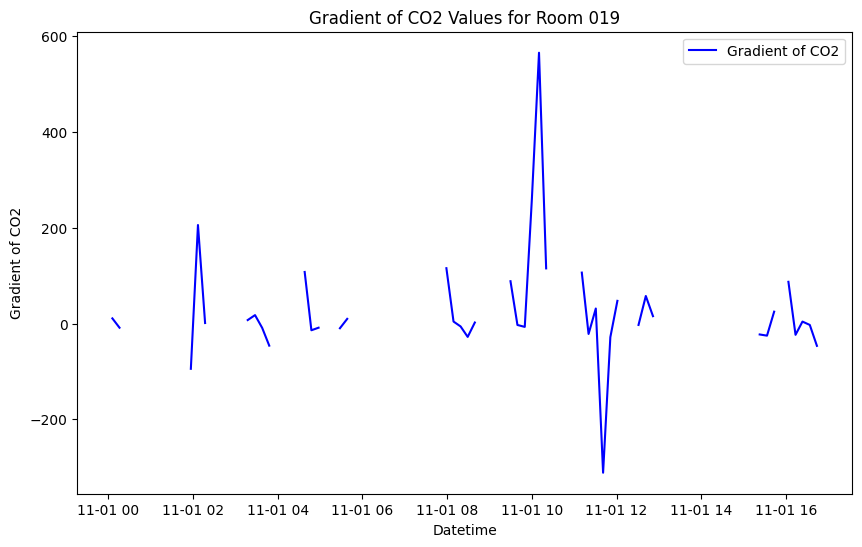

Room: Room 054, Gradient of CO2 values:


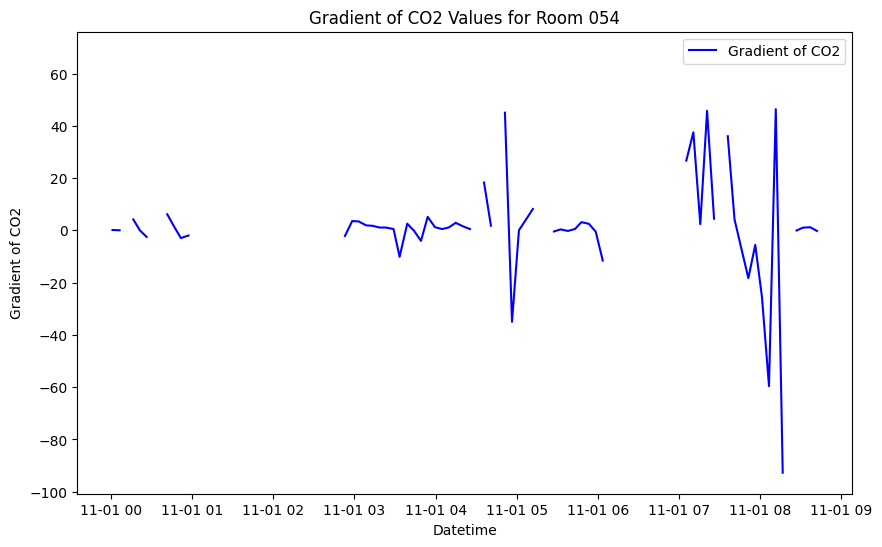

Room: Room 001, Gradient of CO2 values:


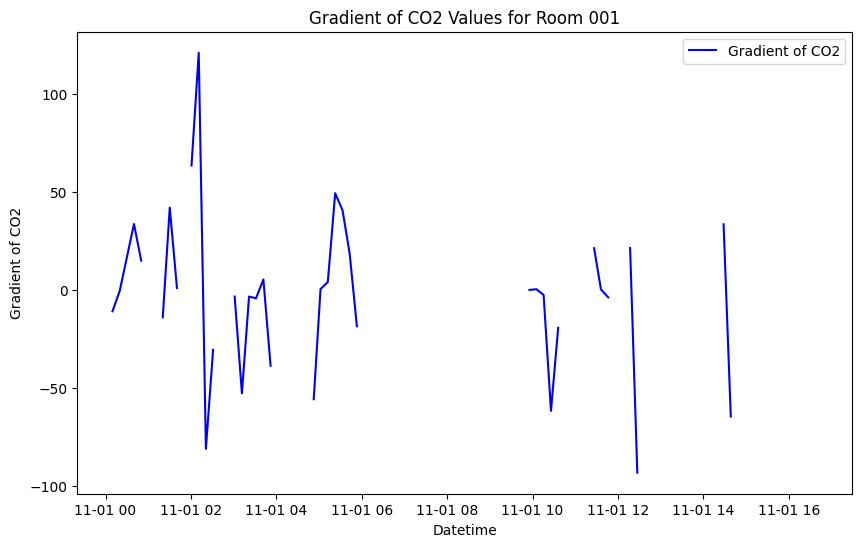

Room: Room 015, Gradient of CO2 values:


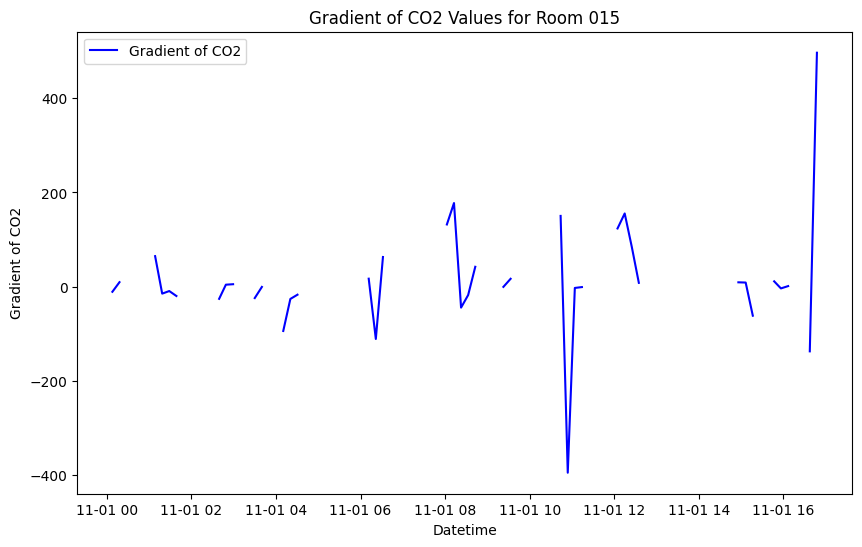

Room: Room 016, Gradient of CO2 values:


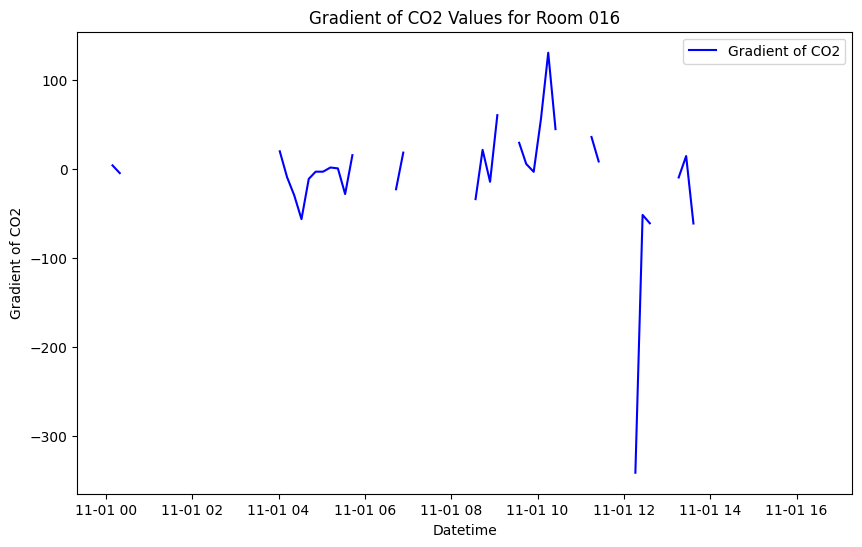

Room: Room 007, Gradient of CO2 values:


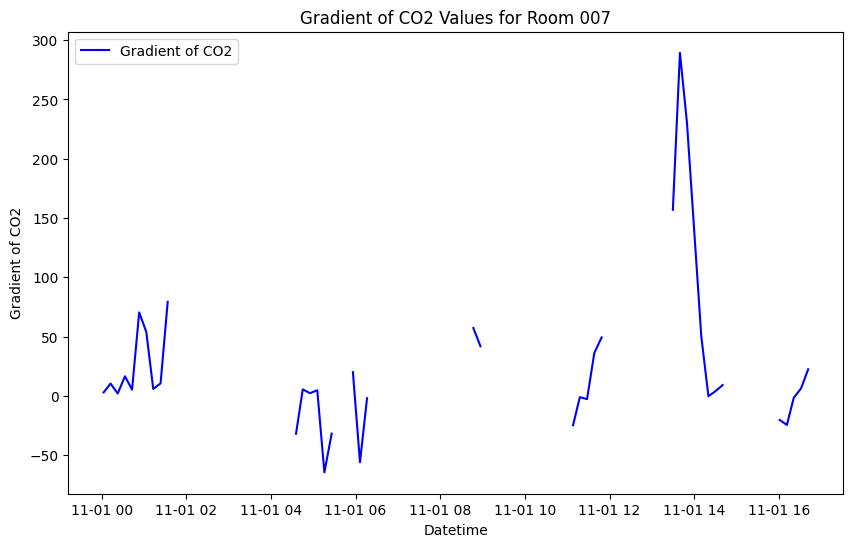

Room: Room 012, Gradient of CO2 values:


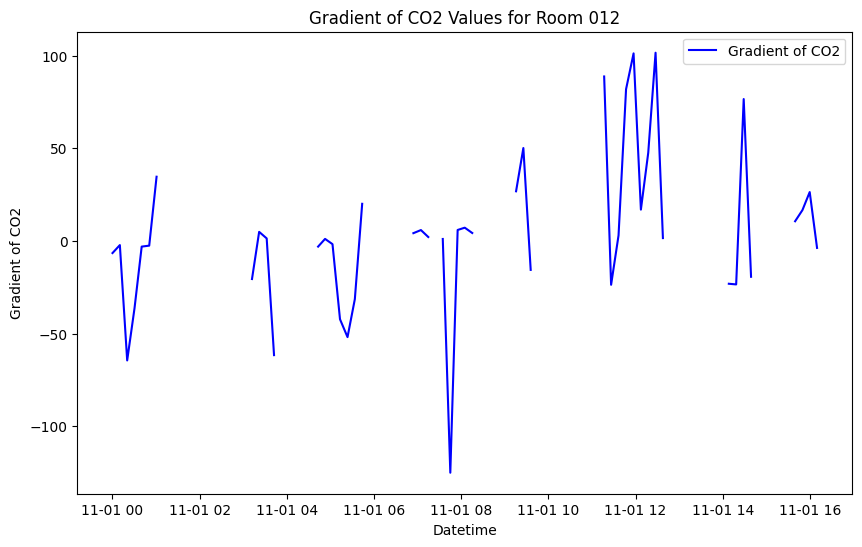

Room: Room 004, Gradient of CO2 values:


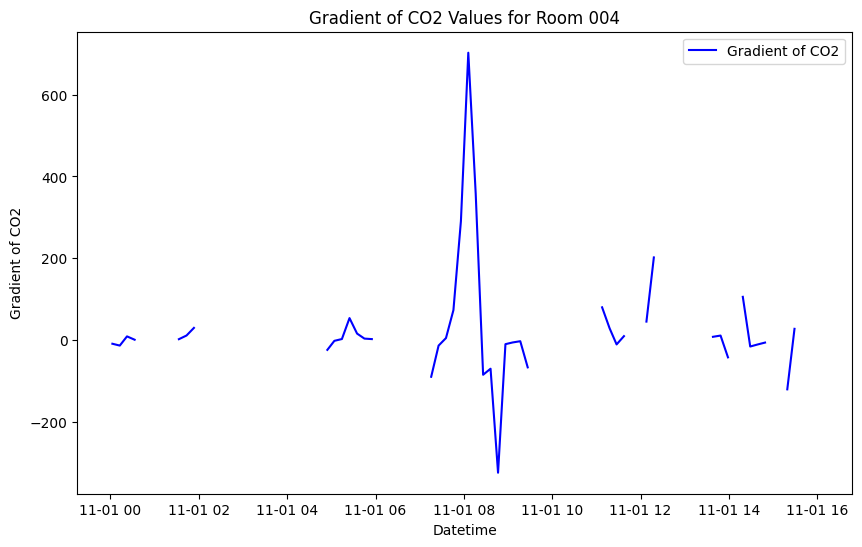

Room: Room 010, Gradient of CO2 values:


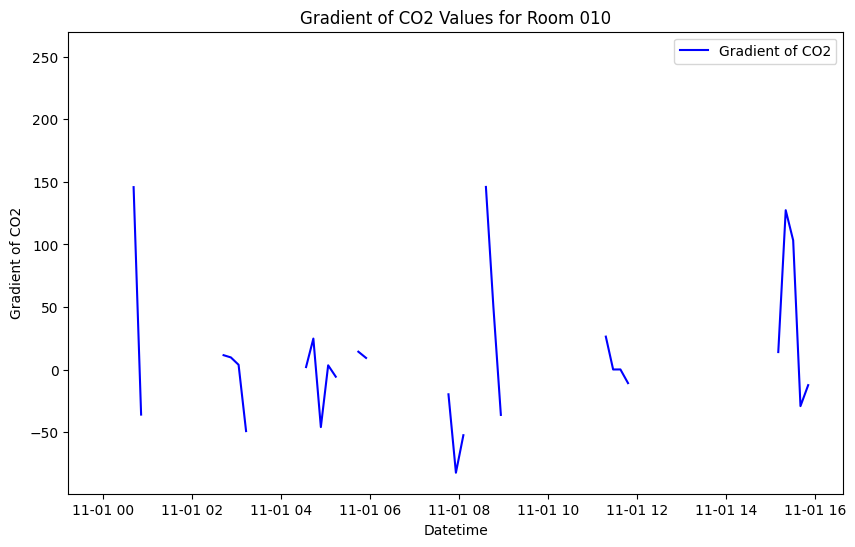

Room: Room 039, Gradient of CO2 values:


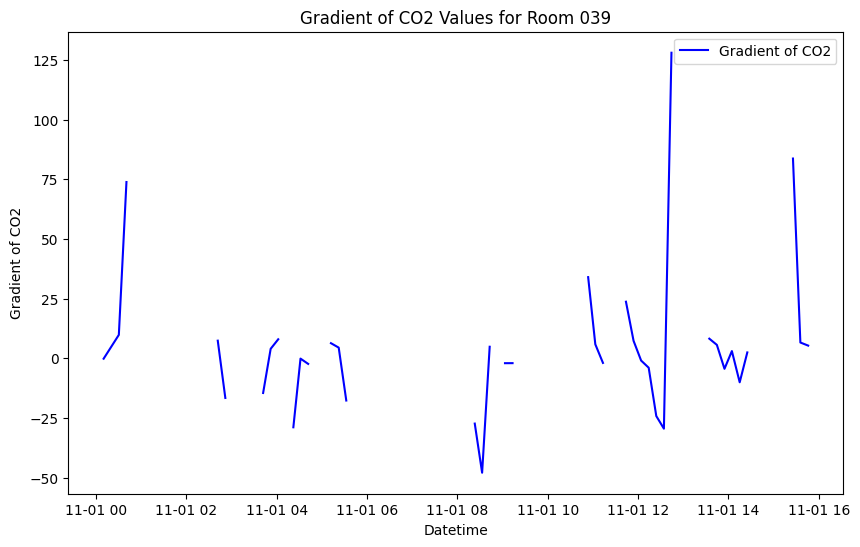

In [142]:
FIRST_OBS = 100

for room_name, data in df_series_cleaned.items():
    #Finting the gradient of the co2 values 
    waiting_time = data['datetime'].diff().dt.total_seconds()
    gradient = np.gradient(data['co2'].values, waiting_time.fillna(SECONDS_PER_OBS).values)  # Use SECONDS_PER_OBS for the first value

    print(f"Room: {room_name}, Gradient of CO2 values:")
    plt.figure(figsize=(10, 6))
    plt.plot(data['datetime'][:FIRST_OBS], gradient[:FIRST_OBS], label='Gradient of CO2', color='blue')
    plt.title(f"Gradient of CO2 Values for {room_name}")
    plt.xlabel("Datetime")
    plt.ylabel("Gradient of CO2")
    plt.legend()
    plt.show()

# Fitting Models

We now try to fit a Continuous Hidden Markov Model to the CO2 data. 

The models we will fit are: 
1. Gaussian HMM with static transitions 
2. Gaussian HMM with time-varying transitions 
3. Auto-regressive HMM with static transitions
4. Auto-regressive HMM with time-varying transitions 


